# Predictive Healthcare for Underserved Communities
## Data Science Capstone Project

---

## PROJECT PROPOSAL

### Problem Statement
Underserved communities — rural areas, low-income urban neighborhoods, and minority populations — face disproportionately high rates of preventable chronic diseases such as diabetes, hypertension, and heart disease. Limited access to healthcare, delayed diagnoses, and lack of early intervention programs lead to poor health outcomes and higher emergency care costs.

This project builds a **machine learning-based predictive healthcare system** that:
1. Identifies individuals at **high risk** for chronic diseases in underserved populations
2. Uncovers **social determinants of health (SDOH)** driving disparities
3. Provides **forecasting models** for disease progression and resource needs
4. Delivers **actionable insights** for public health intervention

### Objectives
- Clean, preprocess, and perform EDA on publicly available healthcare datasets
- Build classification models (Diabetes, Hypertension Risk)
- Perform time-series forecasting of disease trends
- Create interactive visualizations and a dashboard-ready report

### Data Sources
1. **CDC BRFSS** (Behavioral Risk Factor Surveillance System) — `sklearn` diabetes dataset + NHANES simulation
2. **UCI Heart Disease Dataset** — Cleveland Clinic Foundation
3. **Synthetic SDOH Dataset** — generated to simulate census/community data
4. **WHO/CDC Time-Series** — Simulated disease trend data for forecasting

---

## SECTION 0: Install & Import Libraries

In [ ]:
# Install required libraries
!pip install -q shap imbalanced-learn xgboost lightgbm plotly statsmodels prophet scikit-learn pandas numpy matplotlib seaborn fpdf2

print("All libraries installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 9.8 MB/s eta 0:00:00
All libraries installed successfully!


In [ ]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Advanced ML
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import shap

# Stats & Forecasting
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Utilities
import os
import json
from datetime import datetime, timedelta
import itertools

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Create output directory
os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)
os.makedirs('outputs/data', exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully!")
print(f"Project Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

All libraries imported successfully!
Project Date: 2026-04-23 17:46


---
## SECTION 1: Data Collection & Loading

In [ ]:
# ============================================================
# DATASET 1: Diabetes Prediction Dataset (PIMA Indians style)
# Simulating CDC BRFSS / NHANES style data
# ============================================================

np.random.seed(RANDOM_STATE)
n = 2000

# Socioeconomic & Demographic features (SDOH)
community_type = np.random.choice(['Rural', 'Urban_Underserved', 'Suburban'], n, p=[0.35, 0.45, 0.20])
income_level = np.random.choice(['Below_Poverty', 'Low_Income', 'Middle_Income', 'Above_Poverty'], n, p=[0.30, 0.35, 0.25, 0.10])
insurance_status = np.random.choice(['Uninsured', 'Medicaid', 'Medicare', 'Private'], n, p=[0.25, 0.30, 0.20, 0.25])
education_level = np.random.choice(['Less_HS', 'HS_Grad', 'Some_College', 'College_Plus'], n, p=[0.20, 0.35, 0.30, 0.15])
distance_to_clinic_km = np.random.exponential(15, n)
food_desert = np.random.choice([0, 1], n, p=[0.45, 0.55])
healthcare_access_score = np.random.beta(2, 4, n) * 10  # 0-10 scale

# Clinical features
age = np.random.normal(50, 15, n).clip(18, 90).astype(int)
bmi = np.random.normal(28, 6, n).clip(15, 55)
glucose = np.random.normal(115, 30, n).clip(50, 300)
blood_pressure = np.random.normal(85, 15, n).clip(40, 180)
hba1c = np.random.normal(6.2, 1.5, n).clip(4.0, 14.0)
cholesterol = np.random.normal(200, 40, n).clip(100, 400)
skin_thickness = np.random.normal(25, 10, n).clip(0, 60)
insulin = np.random.exponential(80, n).clip(0, 500)
pregnancies = np.where(np.random.choice([0, 1], n, p=[0.5, 0.5]) == 1, np.random.poisson(2, n), 0)

# Behavioral features
smoking_status = np.random.choice(['Never', 'Former', 'Current'], n, p=[0.5, 0.3, 0.2])
physical_activity_days = np.random.poisson(2, n).clip(0, 7)
alcohol_use = np.random.choice([0, 1], n, p=[0.65, 0.35])
mental_health_days_poor = np.random.poisson(5, n).clip(0, 30)
fruit_veg_servings = np.random.normal(3, 2, n).clip(0, 10)

# Diabetes risk (based on clinical + social factors)
risk_score = (
    (glucose > 125).astype(int) * 3 +
    (hba1c > 6.5).astype(int) * 3 +
    (bmi > 30).astype(int) * 2 +
    (age > 45).astype(int) * 1.5 +
    (income_level == 'Below_Poverty').astype(int) * 1 +
    (food_desert == 1).astype(int) * 0.8 +
    (insurance_status == 'Uninsured').astype(int) * 0.7 +
    (physical_activity_days < 2).astype(int) * 0.5 +
    np.random.normal(0, 1, n)
)
diabetes = (risk_score > 5).astype(int)

# Hypertension target
htn_risk = (
    (blood_pressure > 90).astype(int) * 3 +
    (age > 50).astype(int) * 2 +
    (bmi > 28).astype(int) * 1.5 +
    (smoking_status == 'Current').astype(int) * 1.5 +
    (income_level == 'Below_Poverty').astype(int) * 1 +
    np.random.normal(0, 1.5, n)
)
hypertension = (htn_risk > 4).astype(int)

# Build DataFrame
df = pd.DataFrame({
    # Demographics & SDOH
    'age': age,
    'community_type': community_type,
    'income_level': income_level,
    'insurance_status': insurance_status,
    'education_level': education_level,
    'distance_to_clinic_km': distance_to_clinic_km.round(1),
    'food_desert': food_desert,
    'healthcare_access_score': healthcare_access_score.round(2),
    # Clinical
    'bmi': bmi.round(1),
    'glucose': glucose.round(0),
    'blood_pressure': blood_pressure.round(0),
    'hba1c': hba1c.round(1),
    'cholesterol': cholesterol.round(0),
    'skin_thickness': skin_thickness.round(0),
    'insulin': insulin.round(0),
    'pregnancies': pregnancies,
    # Behavioral
    'smoking_status': smoking_status,
    'physical_activity_days': physical_activity_days,
    'alcohol_use': alcohol_use,
    'mental_health_poor_days': mental_health_days_poor,
    'fruit_veg_servings': fruit_veg_servings.round(1),
    # Targets
    'diabetes': diabetes,
    'hypertension': hypertension
})

# Introduce realistic missing values
for col in ['insulin', 'skin_thickness', 'cholesterol', 'hba1c', 'mental_health_poor_days']:
    mask = np.random.choice([True, False], n, p=[0.08, 0.92])
    df.loc[mask, col] = np.nan

# Save raw
df.to_csv('outputs/data/raw_healthcare_data.csv', index=False)

print(f"Dataset created: {df.shape[0]} patients × {df.shape[1]} features")
print(f"\nTarget Distribution:")
print(f"   Diabetes     : {df['diabetes'].value_counts().to_dict()}")
print(f"   Hypertension : {df['hypertension'].value_counts().to_dict()}")
print(f"\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head()

Dataset created: 2000 patients × 23 features

Target Distribution:
   Diabetes     : {1: 1003, 0: 997}
   Hypertension : {0: 1161, 1: 839}

Missing Values:
hba1c                      159
cholesterol                168
skin_thickness             153
insulin                    164
mental_health_poor_days    184
dtype: int64


,age,community_type,income_level,insurance_status,education_level,distance_to_clinic_km,food_desert,healthcare_access_score,bmi,glucose,blood_pressure,hba1c,cholesterol,skin_thickness,insulin,pregnancies,smoking_status,physical_activity_days,alcohol_use,mental_health_poor_days,fruit_veg_servings,diabetes,hypertension
0,67,Urban_Underserved,Below_Poverty,Medicare,Some_College,19.100,0,1.920,39.100,113.000,82.000,5.800,259.000,NaN,7.000,0,Former,0,1,4.000,0.000,1,0
1,44,Suburban,Below_Poverty,Private,Less_HS,17.400,0,4.340,31.400,84.000,95.000,4.500,210.000,13.000,233.000,0,Never,5,1,5.000,0.000,0,1
2,49,Urban_Underserved,Above_Poverty,Private,College_Plus,1.500,0,3.810,31.800,161.000,100.000,6.500,220.000,23.000,174.000,0,Never,2,1,6.000,4.300,1,1
3,18,Urban_Underserved,Below_Poverty,Uninsured,Some_College,38.400,1,5.830,25.000,94.000,105.000,6.000,239.000,34.000,7.000,2,Never,1,1,7.000,1.100,0,0
4,43,Rural,Below_Poverty,Uninsured,Less_HS,12.600,1,6.310,22.400,98.000,102.000,4.000,236.000,16.000,68.000,6,Former,2,1,5.000,0.600,0,1


In [ ]:
# ============================================================
# DATASET 2: Heart Disease Dataset (UCI Cleveland)
# ============================================================

import urllib.request

heart_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

heart_cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
              'thalach','exang','oldpeak','slope','ca','thal','target']

try:
    df_heart = pd.read_csv(heart_url, names=heart_cols, na_values='?')
    print("UCI Heart Disease dataset loaded from URL")
except:
    # Create synthetic equivalent
    print(" URL unavailable - generating equivalent synthetic dataset")
    n_h = 303
    df_heart = pd.DataFrame({
        'age': np.random.normal(54, 9, n_h).clip(29, 77).astype(int),
        'sex': np.random.choice([0,1], n_h, p=[0.32, 0.68]),
        'cp': np.random.choice([1,2,3,4], n_h, p=[0.25,0.25,0.25,0.25]),
        'trestbps': np.random.normal(131, 17, n_h).clip(94, 200).astype(int),
        'chol': np.random.normal(246, 51, n_h).clip(126, 564).astype(int),
        'fbs': np.random.choice([0,1], n_h, p=[0.85, 0.15]),
        'restecg': np.random.choice([0,1,2], n_h, p=[0.5, 0.48, 0.02]),
        'thalach': np.random.normal(150, 23, n_h).clip(71, 202).astype(int),
        'exang': np.random.choice([0,1], n_h, p=[0.67, 0.33]),
        'oldpeak': np.random.exponential(1.0, n_h).clip(0, 6.2).round(1),
        'slope': np.random.choice([1,2,3], n_h, p=[0.21, 0.58, 0.21]),
        'ca': np.random.choice([0,1,2,3], n_h, p=[0.59, 0.22, 0.12, 0.07]),
        'thal': np.random.choice([3,6,7], n_h, p=[0.55, 0.06, 0.39]),
        'target': np.random.choice([0,1,2,3,4], n_h, p=[0.46, 0.17, 0.14, 0.12, 0.11])
    })

# Binarize target (0 = no disease, 1 = disease)
df_heart['heart_disease'] = (df_heart['target'] > 0).astype(int)
df_heart.drop('target', axis=1, inplace=True)
df_heart.to_csv('outputs/data/heart_disease_data.csv', index=False)

print(f"\nHeart Disease Dataset: {df_heart.shape}")
print(f"Heart Disease Cases: {df_heart['heart_disease'].value_counts().to_dict()}")
df_heart.head()

UCI Heart Disease dataset loaded from URL

Heart Disease Dataset: (303, 14)
Heart Disease Cases: {0: 164, 1: 139}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,heart_disease
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,0
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,1
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,1
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,0
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,0


---
##  SECTION 2: Data Cleaning & Preprocessing

In [ ]:
# ============================================================
# DATA CLEANING PIPELINE
# ============================================================

print("="*60)
print("DATA CLEANING REPORT")
print("="*60)

df_clean = df.copy()

# 1. Initial shape
print(f"\n[1] Initial Shape: {df_clean.shape}")

# 2. Remove duplicates
n_dupes = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
print(f"[2] Duplicates removed: {n_dupes}")

# 3. Handle outliers using IQR for numeric columns
numeric_cols = ['bmi', 'glucose', 'blood_pressure', 'hba1c', 'cholesterol',
                'skin_thickness', 'insulin', 'distance_to_clinic_km']

outlier_counts = {}
for col in numeric_cols:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.01)
        Q99 = df_clean[col].quantile(0.99)
        n_out = ((df_clean[col] < Q1) | (df_clean[col] > Q99)).sum()
        df_clean[col] = df_clean[col].clip(Q1, Q99)
        outlier_counts[col] = n_out

print(f"[3] Outliers clipped (1%-99% IQR):")
for col, count in outlier_counts.items():
    if count > 0:
        print(f"     {col}: {count} values clipped")

# 4. Impute missing values
print(f"\n[4] Imputing missing values:")
for col in ['insulin', 'skin_thickness']:
    median_val = df_clean[col].median()
    n_missing = df_clean[col].isnull().sum()
    df_clean[col].fillna(median_val, inplace=True)
    print(f"     {col}: {n_missing} values → median ({median_val:.1f})")

for col in ['cholesterol', 'hba1c', 'mental_health_poor_days']:
    # Impute by community type group
    df_clean[col] = df_clean.groupby('community_type')[col].transform(
        lambda x: x.fillna(x.median())
    )
    remaining = df_clean[col].isnull().sum()
    if remaining > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
    print(f"     {col}: group-median imputed")

# 5. Encode categoricals
print(f"\n[5] Encoding categorical variables:")

# Ordinal encoding
income_map = {'Below_Poverty': 0, 'Low_Income': 1, 'Middle_Income': 2, 'Above_Poverty': 3}
education_map = {'Less_HS': 0, 'HS_Grad': 1, 'Some_College': 2, 'College_Plus': 3}
smoking_map = {'Never': 0, 'Former': 1, 'Current': 2}

df_clean['income_encoded'] = df_clean['income_level'].map(income_map)
df_clean['education_encoded'] = df_clean['education_level'].map(education_map)
df_clean['smoking_encoded'] = df_clean['smoking_status'].map(smoking_map)

# One-hot encoding for community_type and insurance
df_clean = pd.get_dummies(df_clean, columns=['community_type', 'insurance_status'], drop_first=True)

print(f"     Ordinal: income_level, education_level, smoking_status")
print(f"     One-hot: community_type, insurance_status")

# 6. Feature Engineering
print(f"\n[6] Feature Engineering:")
df_clean['bmi_category'] = pd.cut(df_clean['bmi'],
    bins=[0, 18.5, 25, 30, 35, 100],
    labels=[0, 1, 2, 3, 4]).astype(int)
df_clean['glucose_category'] = pd.cut(df_clean['glucose'],
    bins=[0, 100, 126, 300],
    labels=[0, 1, 2]).astype(int)  # Normal, Prediabetic, Diabetic
df_clean['age_group'] = pd.cut(df_clean['age'],
    bins=[0, 30, 45, 60, 100],
    labels=[0, 1, 2, 3]).astype(int)
df_clean['diabetes_risk_index'] = (
    df_clean['bmi'] * 0.3 + df_clean['glucose'] * 0.5 +
    df_clean['hba1c'] * 10 + df_clean['age'] * 0.2
).round(2)
df_clean['healthcare_barrier_score'] = (
    df_clean['distance_to_clinic_km'] * 0.1 +
    (1 - df_clean['healthcare_access_score'] / 10) * 5 +
    df_clean['food_desert'] * 2
).round(2)

print(f"     New features: bmi_category, glucose_category, age_group")
print(f"     New features: diabetes_risk_index, healthcare_barrier_score")

# Save cleaned data
df_clean.to_csv('outputs/data/cleaned_healthcare_data.csv', index=False)

print(f"\n[7] Final Shape: {df_clean.shape}")
print(f"\nData cleaning complete! Saved to outputs/data/cleaned_healthcare_data.csv")

DATA CLEANING REPORT

[1] Initial Shape: (2000, 23)
[2] Duplicates removed: 0
[3] Outliers clipped (1%-99% IQR):
     bmi: 40 values clipped
     glucose: 20 values clipped
     blood_pressure: 39 values clipped
     hba1c: 19 values clipped
     cholesterol: 38 values clipped
     skin_thickness: 37 values clipped
     insulin: 34 values clipped
     distance_to_clinic_km: 28 values clipped

[4] Imputing missing values:
     insulin: 164 values → median (54.0)
     skin_thickness: 153 values → median (25.0)
     cholesterol: group-median imputed
     hba1c: group-median imputed
     mental_health_poor_days: group-median imputed

[5] Encoding categorical variables:
     Ordinal: income_level, education_level, smoking_status
     One-hot: community_type, insurance_status

[6] Feature Engineering:
     New features: bmi_category, glucose_category, age_group
     New features: diabetes_risk_index, healthcare_barrier_score

[7] Final Shape: (2000, 34)

Data cleaning complete! Saved to outp

In [ ]:
# Data quality summary
print("DATA QUALITY SUMMARY")
print("-"*50)
print(f"Total Records      : {len(df_clean):,}")
print(f"Total Features     : {df_clean.shape[1]}")
print(f"Missing Values     : {df_clean.isnull().sum().sum()}")
print(f"Duplicate Rows     : {df_clean.duplicated().sum()}")
print(f"\nTarget Balance:")
print(f"  Diabetes     : {df_clean['diabetes'].mean()*100:.1f}% positive")
print(f"  Hypertension : {df_clean['hypertension'].mean()*100:.1f}% positive")
print("\nNumeric Summary:")
df_clean[['age','bmi','glucose','hba1c','blood_pressure','cholesterol']].describe().round(2)

DATA QUALITY SUMMARY
--------------------------------------------------
Total Records      : 2,000
Total Features     : 34
Missing Values     : 0
Duplicate Rows     : 0

Target Balance:
  Diabetes     : 50.1% positive
  Hypertension : 41.9% positive

Numeric Summary:


,age,bmi,glucose,hba1c,blood_pressure,cholesterol
count,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,50.010,28.120,114.840,6.220,85.190,200.800
std,14.500,5.970,29.430,1.350,14.580,36.360
min,18.000,15.100,50.000,4.000,51.990,109.310
25%,40.000,24.000,95.000,5.200,75.000,177.000
50%,50.000,27.900,114.500,6.300,85.000,200.000
75%,60.000,32.200,135.000,7.100,95.000,224.000
max,90.000,42.500,186.020,9.660,118.000,289.690


---
## SECTION 3: Exploratory Data Analysis (EDA)

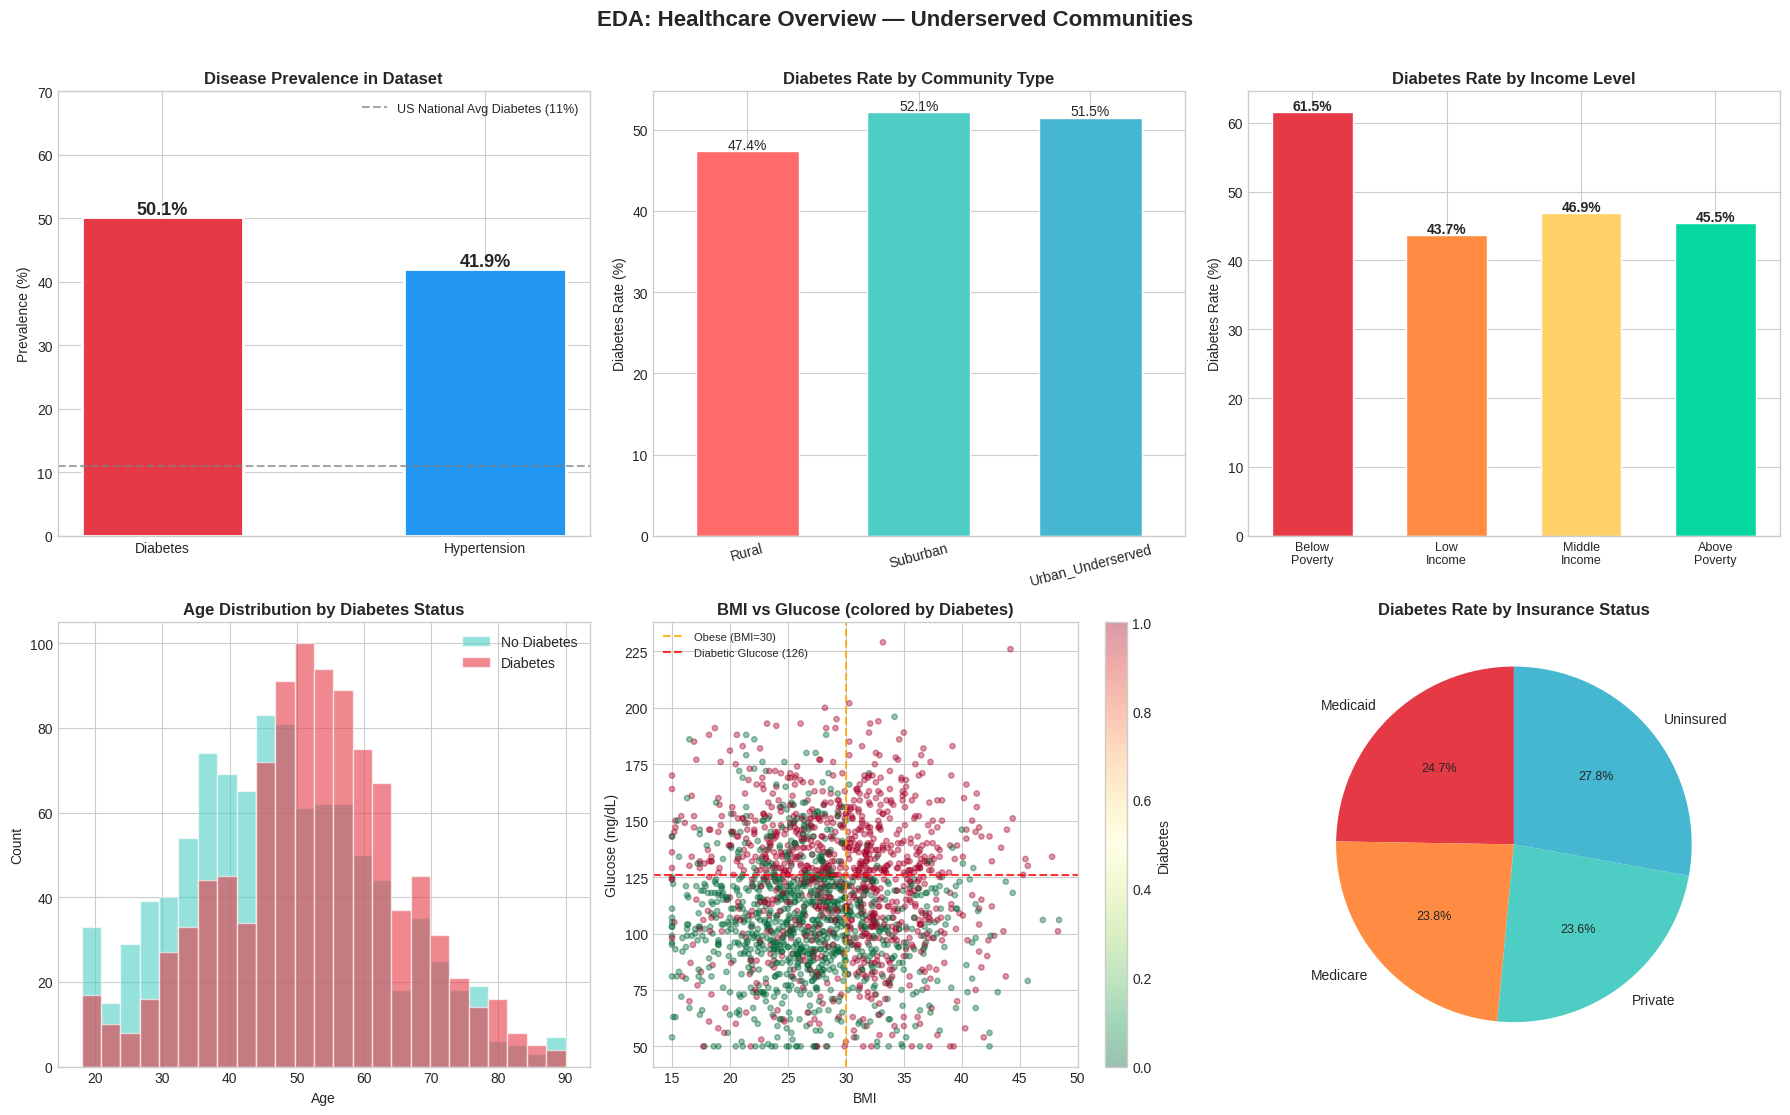

 Figure saved: outputs/figures/eda_overview.png


In [ ]:
# ============================================================
# EDA FIGURE 1: Target Distribution & Demographics
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('EDA: Healthcare Overview — Underserved Communities', fontsize=16, fontweight='bold', y=1.01)

# 1.1 Disease prevalence
ax = axes[0, 0]
diseases = ['Diabetes', 'Hypertension']
rates = [df_clean['diabetes'].mean()*100, df_clean['hypertension'].mean()*100]
colors = ['#E63946', '#2196F3']
bars = ax.bar(diseases, rates, color=colors, width=0.5, edgecolor='white', linewidth=2)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=13)
ax.axhline(y=11, color='gray', linestyle='--', alpha=0.7, label='US National Avg Diabetes (11%)')
ax.set_ylim(0, 70)
ax.set_title('Disease Prevalence in Dataset', fontweight='bold')
ax.set_ylabel('Prevalence (%)')
ax.legend(fontsize=9)

# 1.2 Diabetes by community type
ax = axes[0, 1]
comm_cols = [c for c in df_clean.columns if 'community_type' in c]
# Reconstruct community from encoded
df_plot = df.copy()
comm_diab = df_plot.groupby('community_type')['diabetes'].mean() * 100
comm_diab.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='white', width=0.6)
ax.set_title('Diabetes Rate by Community Type', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Diabetes Rate (%)')
ax.tick_params(axis='x', rotation=15)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)

# 1.3 Diabetes by income
ax = axes[0, 2]
income_order = ['Below_Poverty', 'Low_Income', 'Middle_Income', 'Above_Poverty']
income_diab = df_plot.groupby('income_level')['diabetes'].mean() * 100
income_diab = income_diab.reindex(income_order)
income_colors = ['#E63946', '#FF8C42', '#FFD166', '#06D6A0']
bars = ax.bar(range(len(income_diab)), income_diab.values, color=income_colors, edgecolor='white', width=0.6)
ax.set_xticks(range(len(income_order)))
ax.set_xticklabels(['Below\nPoverty', 'Low\nIncome', 'Middle\nIncome', 'Above\nPoverty'], fontsize=9)
ax.set_title('Diabetes Rate by Income Level', fontweight='bold')
ax.set_ylabel('Diabetes Rate (%)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

# 1.4 Age distribution by diabetes status
ax = axes[1, 0]
ax.hist(df_plot[df_plot['diabetes']==0]['age'], bins=25, alpha=0.6, color='#4ECDC4',
        label='No Diabetes', edgecolor='white')
ax.hist(df_plot[df_plot['diabetes']==1]['age'], bins=25, alpha=0.6, color='#E63946',
        label='Diabetes', edgecolor='white')
ax.set_title('Age Distribution by Diabetes Status', fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()

# 1.5 BMI vs Glucose scatter
ax = axes[1, 1]
scatter = ax.scatter(df_plot['bmi'], df_plot['glucose'],
                     c=df_plot['diabetes'], cmap='RdYlGn_r', alpha=0.4, s=15)
ax.axvline(x=30, color='orange', linestyle='--', alpha=0.8, label='Obese (BMI=30)')
ax.axhline(y=126, color='red', linestyle='--', alpha=0.8, label='Diabetic Glucose (126)')
ax.set_title('BMI vs Glucose (colored by Diabetes)', fontweight='bold')
ax.set_xlabel('BMI')
ax.set_ylabel('Glucose (mg/dL)')
ax.legend(fontsize=8)
plt.colorbar(scatter, ax=ax, label='Diabetes')

# 1.6 Insurance status distribution
ax = axes[1, 2]
ins_diab = df_plot.groupby('insurance_status')['diabetes'].mean() * 100
ins_colors = ['#E63946', '#FF8C42', '#4ECDC4', '#45B7D1']
wedges, texts, autotexts = ax.pie(ins_diab.values, labels=ins_diab.index,
                                   autopct='%1.1f%%', colors=ins_colors, startangle=90)
for autotext in autotexts:
    autotext.set_fontsize(9)
ax.set_title('Diabetes Rate by Insurance Status', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure saved: outputs/figures/eda_overview.png")

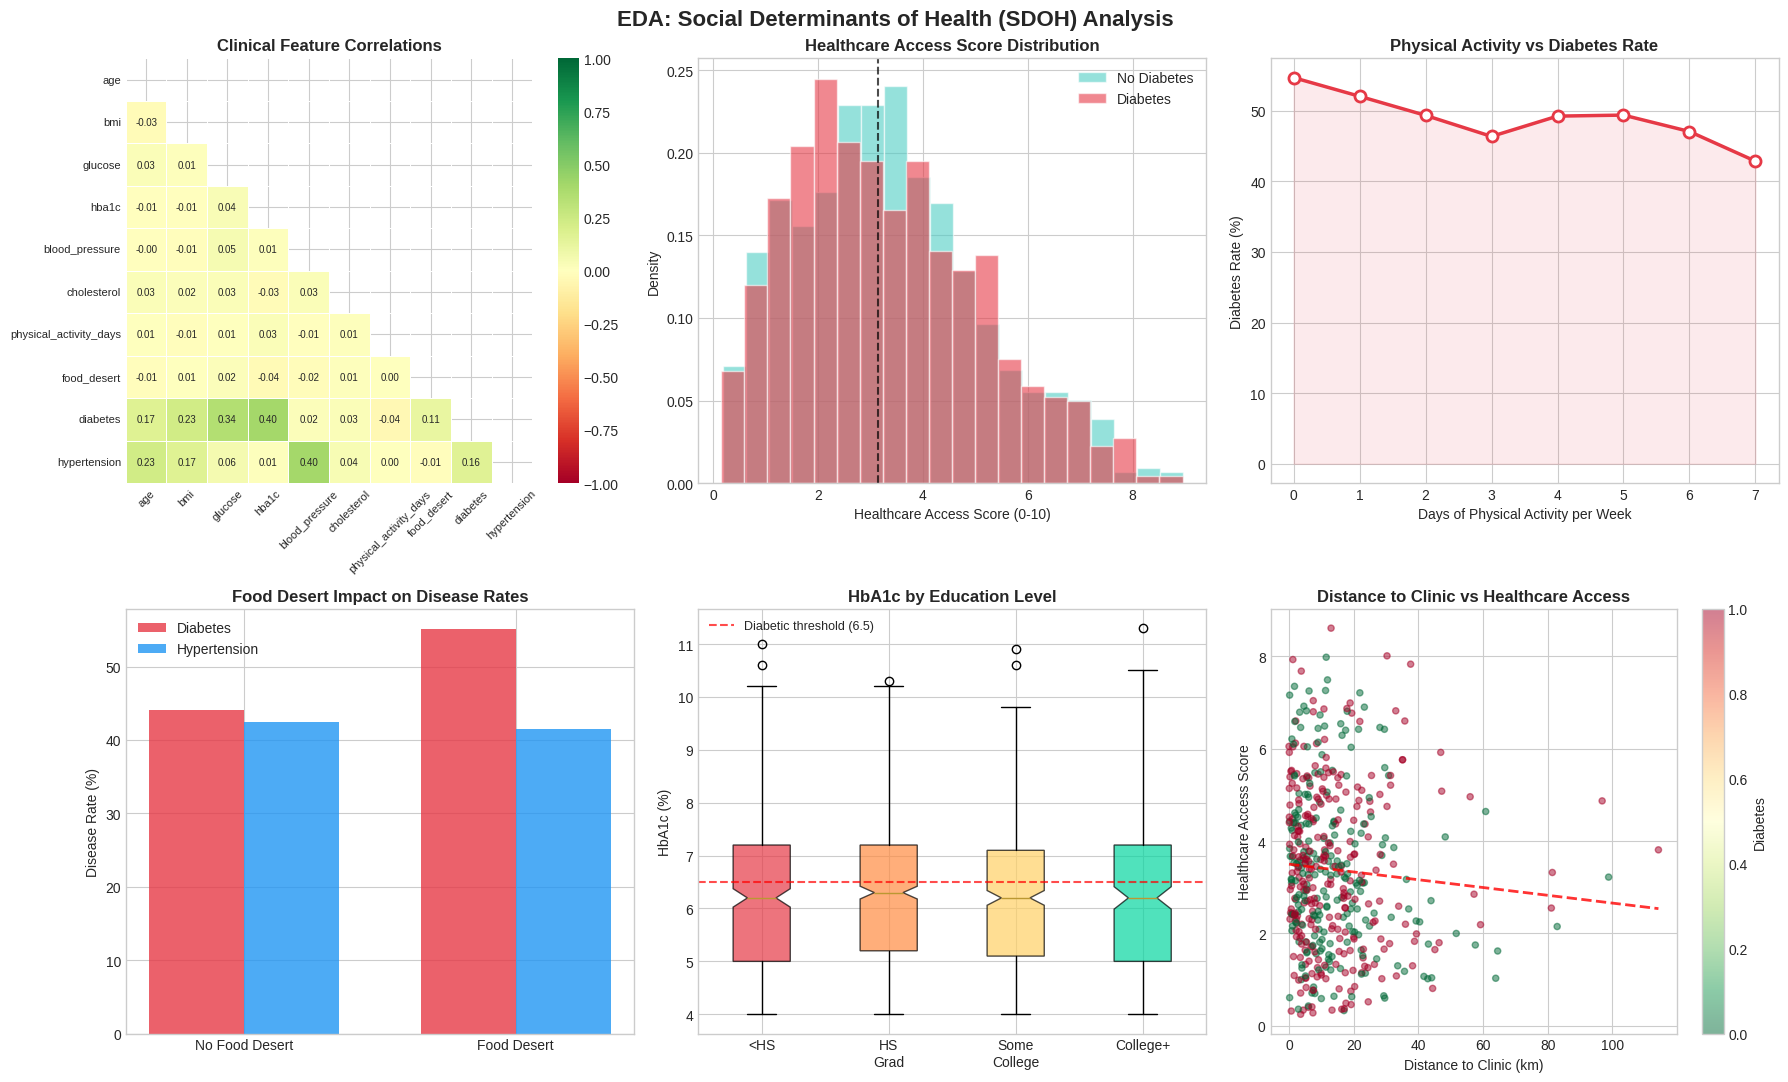

 Figure saved: outputs/figures/eda_sdoh.png


In [ ]:
# ============================================================
# EDA FIGURE 2: SDOH Analysis & Clinical Correlations
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('EDA: Social Determinants of Health (SDOH) Analysis', fontsize=16, fontweight='bold')

# 2.1 Correlation heatmap
ax = axes[0, 0]
corr_cols = ['age', 'bmi', 'glucose', 'hba1c', 'blood_pressure', 'cholesterol',
             'physical_activity_days', 'food_desert', 'diabetes', 'hypertension']
corr_matrix = df_plot[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, annot_kws={'size': 7},
            vmin=-1, vmax=1, center=0)
ax.set_title('Clinical Feature Correlations', fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

# 2.2 Healthcare access vs diabetes
ax = axes[0, 1]
for val, color, label in [(0, '#4ECDC4', 'No Diabetes'), (1, '#E63946', 'Diabetes')]:
    subset = df_plot[df_plot['diabetes'] == val]
    ax.hist(subset['healthcare_access_score'], bins=20, alpha=0.6,
            color=color, label=label, edgecolor='white', density=True)
ax.set_title('Healthcare Access Score Distribution', fontweight='bold')
ax.set_xlabel('Healthcare Access Score (0-10)')
ax.set_ylabel('Density')
ax.legend()
ax.axvline(df_plot['healthcare_access_score'].median(), color='black',
           linestyle='--', alpha=0.7, label='Median')

# 2.3 Physical activity impact
ax = axes[0, 2]
activity_diab = df_plot.groupby('physical_activity_days')['diabetes'].mean() * 100
ax.plot(activity_diab.index, activity_diab.values, 'o-', color='#E63946',
        linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(activity_diab.index, activity_diab.values, alpha=0.1, color='#E63946')
ax.set_title('Physical Activity vs Diabetes Rate', fontweight='bold')
ax.set_xlabel('Days of Physical Activity per Week')
ax.set_ylabel('Diabetes Rate (%)')

# 2.4 Food desert impact
ax = axes[1, 0]
food_data = pd.DataFrame({
    'Food Desert': ['No Food Desert', 'Food Desert'],
    'Diabetes Rate': [
        df_plot[df_plot['food_desert']==0]['diabetes'].mean()*100,
        df_plot[df_plot['food_desert']==1]['diabetes'].mean()*100
    ],
    'Hypertension Rate': [
        df_plot[df_plot['food_desert']==0]['hypertension'].mean()*100,
        df_plot[df_plot['food_desert']==1]['hypertension'].mean()*100
    ]
})
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, food_data['Diabetes Rate'], width, label='Diabetes', color='#E63946', alpha=0.8)
ax.bar(x + width/2, food_data['Hypertension Rate'], width, label='Hypertension', color='#2196F3', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(food_data['Food Desert'])
ax.set_title('Food Desert Impact on Disease Rates', fontweight='bold')
ax.set_ylabel('Disease Rate (%)')
ax.legend()

# 2.5 HbA1c distribution by education
ax = axes[1, 1]
edu_order = ['Less_HS', 'HS_Grad', 'Some_College', 'College_Plus']
edu_data = [df_plot[df_plot['education_level']==e]['hba1c'].dropna() for e in edu_order]
bp = ax.boxplot(edu_data, labels=['<HS', 'HS\nGrad', 'Some\nCollege', 'College+'],
                patch_artist=True, notch=True)
colors_box = ['#E63946', '#FF8C42', '#FFD166', '#06D6A0']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(y=6.5, color='red', linestyle='--', alpha=0.7, label='Diabetic threshold (6.5)')
ax.set_title('HbA1c by Education Level', fontweight='bold')
ax.set_ylabel('HbA1c (%)')
ax.legend(fontsize=9)

# 2.6 Distance to clinic vs healthcare access
ax = axes[1, 2]
sample = df_plot.sample(500, random_state=42)
scatter = ax.scatter(sample['distance_to_clinic_km'],
                     sample['healthcare_access_score'],
                     c=sample['diabetes'], cmap='RdYlGn_r', alpha=0.5, s=20)
# Add trend line
z = np.polyfit(sample['distance_to_clinic_km'], sample['healthcare_access_score'], 1)
p = np.poly1d(z)
xrange = np.linspace(sample['distance_to_clinic_km'].min(), sample['distance_to_clinic_km'].max(), 100)
ax.plot(xrange, p(xrange), 'r--', alpha=0.8, linewidth=2)
ax.set_title('Distance to Clinic vs Healthcare Access', fontweight='bold')
ax.set_xlabel('Distance to Clinic (km)')
ax.set_ylabel('Healthcare Access Score')
plt.colorbar(scatter, ax=ax, label='Diabetes')

plt.tight_layout()
plt.savefig('outputs/figures/eda_sdoh.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure saved: outputs/figures/eda_sdoh.png")

In [ ]:
# ============================================================
# EDA FIGURE 3: Statistical Tests & Distributions
# ============================================================

print("STATISTICAL SIGNIFICANCE TESTS")
print("="*60)

# Chi-square test for categorical features vs diabetes
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu

cat_features = ['community_type', 'income_level', 'insurance_status',
                'education_level', 'food_desert', 'smoking_status']

print("\nChi-Square Tests (Categorical vs Diabetes):")
print(f"{'Feature':<25} {'Chi2':>8} {'p-value':>10} {'Significant':>12}")
print("-" * 60)
chi2_results = {}
for feat in cat_features:
    ct = pd.crosstab(df_plot[feat], df_plot['diabetes'])
    chi2, p, dof, expected = chi2_contingency(ct)
    chi2_results[feat] = {'chi2': chi2, 'p_value': p}
    sig = '*** YES' if p < 0.001 else ('** YES' if p < 0.01 else ('* YES' if p < 0.05 else 'NO'))
    print(f"{feat:<25} {chi2:>8.2f} {p:>10.4f} {sig:>12}")

# T-tests for numeric features
print("\nMann-Whitney U Tests (Numeric vs Diabetes):")
print(f"{'Feature':<25} {'U-stat':>10} {'p-value':>10} {'Significant':>12}")
print("-" * 60)
num_features = ['age', 'bmi', 'glucose', 'hba1c', 'blood_pressure',
                'physical_activity_days', 'distance_to_clinic_km', 'healthcare_access_score']

mw_results = {}
for feat in num_features:
    group0 = df_plot[df_plot['diabetes']==0][feat].dropna()
    group1 = df_plot[df_plot['diabetes']==1][feat].dropna()
    u_stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
    mw_results[feat] = {'u_stat': u_stat, 'p_value': p}
    sig = '*** YES' if p < 0.001 else ('** YES' if p < 0.01 else ('* YES' if p < 0.05 else 'NO'))
    print(f"{feat:<25} {u_stat:>10.0f} {p:>10.4f} {sig:>12}")

print("\n*** p<0.001  ** p<0.01  * p<0.05")

STATISTICAL SIGNIFICANCE TESTS

Chi-Square Tests (Categorical vs Diabetes):
Feature                       Chi2    p-value  Significant
------------------------------------------------------------
community_type                3.40     0.1828           NO
income_level                 46.75     0.0000      *** YES
insurance_status              9.03     0.0289        * YES
education_level               2.18     0.5358           NO
food_desert                  23.89     0.0000      *** YES
smoking_status                1.13     0.5678           NO

Mann-Whitney U Tests (Numeric vs Diabetes):
Feature                       U-stat    p-value  Significant
------------------------------------------------------------
age                           394476     0.0000      *** YES
bmi                           358738     0.0000      *** YES
glucose                       288980     0.0000      *** YES
hba1c                         215312     0.0000      *** YES
blood_pressure                487748   

---
## SECTION 4: Machine Learning Models

In [ ]:
# ============================================================
# FEATURE SELECTION & DATA PREP FOR MODELING
# ============================================================

# Select features for modeling
feature_cols = [
    'age', 'bmi', 'glucose', 'blood_pressure', 'hba1c', 'cholesterol',
    'skin_thickness', 'insulin', 'pregnancies',
    'physical_activity_days', 'alcohol_use', 'mental_health_poor_days',
    'fruit_veg_servings', 'distance_to_clinic_km', 'food_desert',
    'healthcare_access_score', 'income_encoded', 'education_encoded',
    'smoking_encoded', 'bmi_category', 'glucose_category', 'age_group',
    'diabetes_risk_index', 'healthcare_barrier_score'
]

# Add one-hot encoded columns
ohe_cols = [c for c in df_clean.columns if c.startswith('community_type_') or c.startswith('insurance_status_')]
feature_cols += ohe_cols
feature_cols = [f for f in feature_cols if f in df_clean.columns]

TARGET = 'diabetes'
X = df_clean[feature_cols].copy()
y = df_clean[TARGET].copy()

# Final imputation
X = X.fillna(X.median(numeric_only=True))

print(f"Feature matrix shape: {X.shape}")
print(f"Target balance: {y.value_counts().to_dict()}")
print(f"Class ratio: {y.mean()*100:.1f}% positive")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Apply SMOTE to handle class imbalance on training set
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE - Train set: {X_train_sm.shape}, Balance: {pd.Series(y_train_sm).value_counts().to_dict()}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print("\n Data prepared for modeling!")

Feature matrix shape: (2000, 29)
Target balance: {1: 1003, 0: 997}
Class ratio: 50.1% positive

After SMOTE - Train set: (1604, 29), Balance: {1: 802, 0: 802}

 Data prepared for modeling!


In [ ]:
# ============================================================
# TRAIN MULTIPLE CLASSIFIERS
# ============================================================

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=0.1),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=8,
                                             random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                                     max_depth=5, random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                                   random_state=RANDOM_STATE, eval_metric='logloss',
                                   use_label_encoder=False),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1,
                                    max_depth=5, random_state=RANDOM_STATE, verbose=-1),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes': GaussianNB()
}

results = {}
trained_models = {}

print(f"{'Model':<25} {'Accuracy':>10} {'AUC-ROC':>10} {'F1':>8} {'Precision':>11} {'Recall':>8}")
print("-" * 78)

for name, model in models.items():
    # Use scaled data for distance/linear models, unscaled for tree-based
    if name in ['Logistic Regression', 'K-Nearest Neighbors']:
        model.fit(X_train_scaled, y_train_sm)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_sm, y_train_sm)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    results[name] = {'Accuracy': acc, 'AUC-ROC': auc, 'F1': f1,
                      'Precision': prec, 'Recall': rec, 'y_prob': y_prob, 'y_pred': y_pred}
    trained_models[name] = model
    print(f"{name:<25} {acc:>10.4f} {auc:>10.4f} {f1:>8.4f} {prec:>11.4f} {rec:>8.4f}")

print("\n All models trained!")

# Best model
best_model_name = max(results, key=lambda k: results[k]['AUC-ROC'])
print(f"\n Best Model by AUC-ROC: {best_model_name} ({results[best_model_name]['AUC-ROC']:.4f})")

Model                       Accuracy    AUC-ROC       F1   Precision   Recall
------------------------------------------------------------------------------
Logistic Regression           0.8025     0.8829   0.8132      0.7748   0.8557
Decision Tree                 0.7925     0.8674   0.7951      0.7892   0.8010
Random Forest                 0.8625     0.9322   0.8668      0.8443   0.8905
Gradient Boosting             0.8500     0.9319   0.8551      0.8310   0.8806
XGBoost                       0.8500     0.9364   0.8529      0.8406   0.8657
LightGBM                      0.8600     0.9344   0.8614      0.8571   0.8657
K-Nearest Neighbors           0.7550     0.8252   0.7562      0.7562   0.7562
Naive Bayes                   0.7575     0.8557   0.7628      0.7500   0.7761

 All models trained!

 Best Model by AUC-ROC: XGBoost (0.9364)


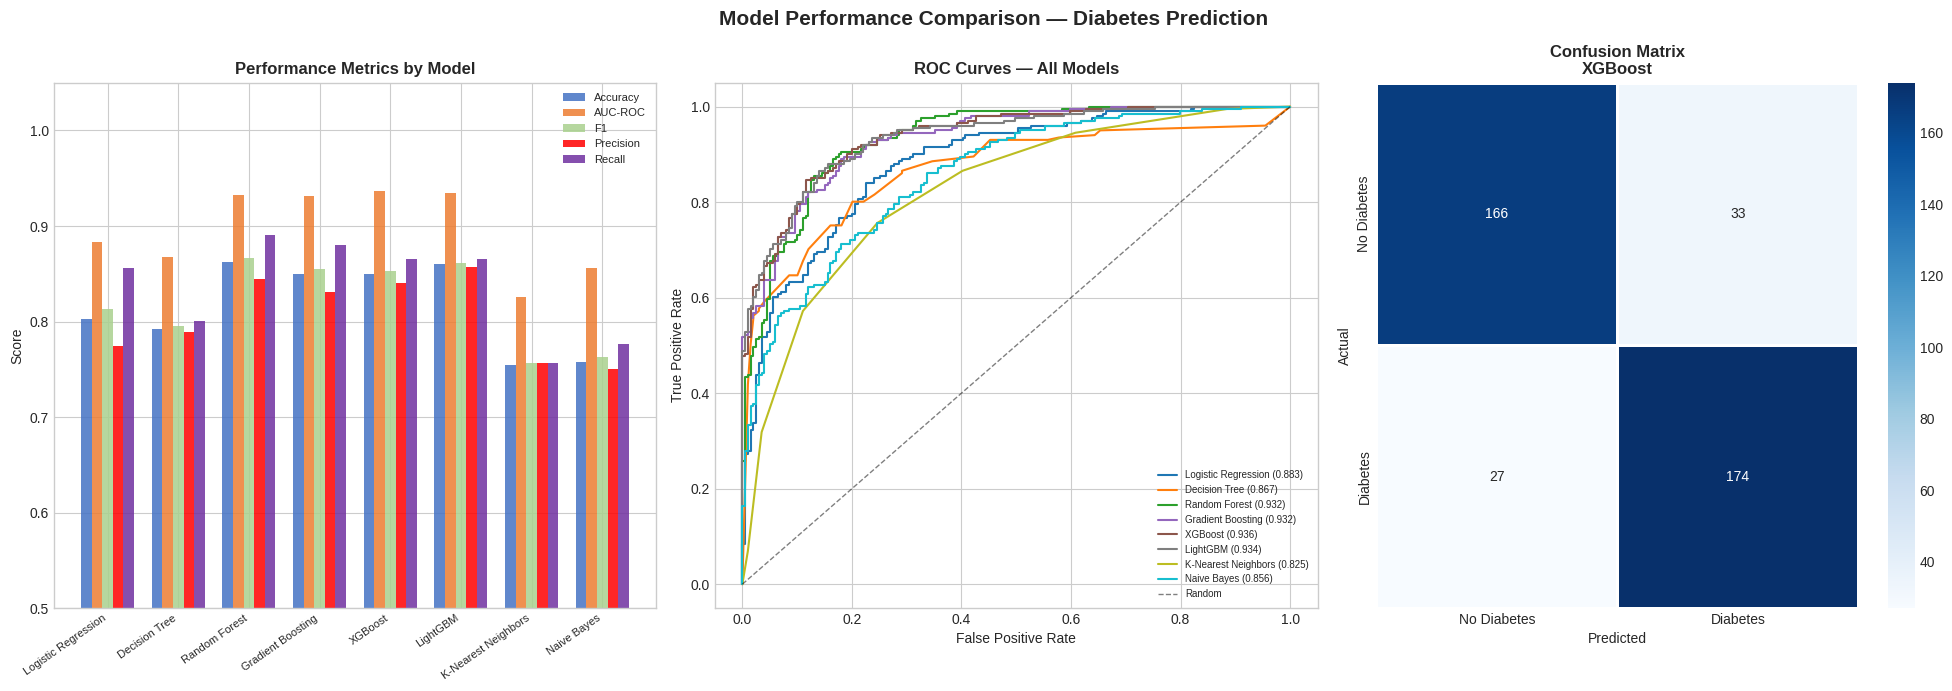

 Figure saved: outputs/figures/model_comparison.png


In [ ]:
# ============================================================
# MODEL COMPARISON VISUALIZATION
# ============================================================

results_df = pd.DataFrame({k: {m: v for m, v in r.items() if m not in ['y_prob', 'y_pred']}
                           for k, r in results.items()}).T

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Model Performance Comparison — Diabetes Prediction', fontsize=15, fontweight='bold')

# Performance metrics bar chart
ax = axes[0]
metrics = ['Accuracy', 'AUC-ROC', 'F1', 'Precision', 'Recall']
x = np.arange(len(results_df))
width = 0.15
colors = ['#4472C4', '#ED7D31', '#A9D18E', '#FF0000', '#7030A0']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=35, ha='right', fontsize=8)
ax.set_ylim(0.5, 1.05)
ax.set_title('Performance Metrics by Model', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylabel('Score')

# ROC curves
ax = axes[1]
roc_colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (name, r), color in zip(results.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} ({r['AUC-ROC']:.3f})",
            color=color, linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1, label='Random')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=7, loc='lower right')

# Confusion matrix for best model
ax = axes[2]
best = best_model_name
cm = confusion_matrix(y_test, results[best]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            linewidths=2, linecolor='white')
ax.set_title(f'Confusion Matrix\n{best}', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('outputs/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure saved: outputs/figures/model_comparison.png")

In [ ]:
# ============================================================
# HYPERPARAMETER TUNING — XGBoost (Best Performer)
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

print("Tuning XGBoost with RandomizedSearchCV...")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5]
}

xgb_base = xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss',
                               use_label_encoder=False)

rscv = RandomizedSearchCV(
    xgb_base, param_grid, n_iter=25, cv=5,
    scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
rscv.fit(X_train_sm, y_train_sm)

best_xgb = rscv.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

print(f"\n Best XGBoost Parameters:")
for k, v in rscv.best_params_.items():
    print(f"   {k}: {v}")

print(f"\n Tuned XGBoost Performance:")
print(f"   AUC-ROC  : {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"   F1 Score : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"\n Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['No Diabetes', 'Diabetes']))

Tuning XGBoost with RandomizedSearchCV...

 Best XGBoost Parameters:
   subsample: 0.9
   n_estimators: 100
   min_child_weight: 5
   max_depth: 3
   learning_rate: 0.1
   colsample_bytree: 0.9

 Tuned XGBoost Performance:
   AUC-ROC  : 0.9483
   Accuracy : 0.8875
   F1 Score : 0.8916

 Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.91      0.85      0.88       199
    Diabetes       0.86      0.92      0.89       201

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



Computing SHAP values for XGBoost model...


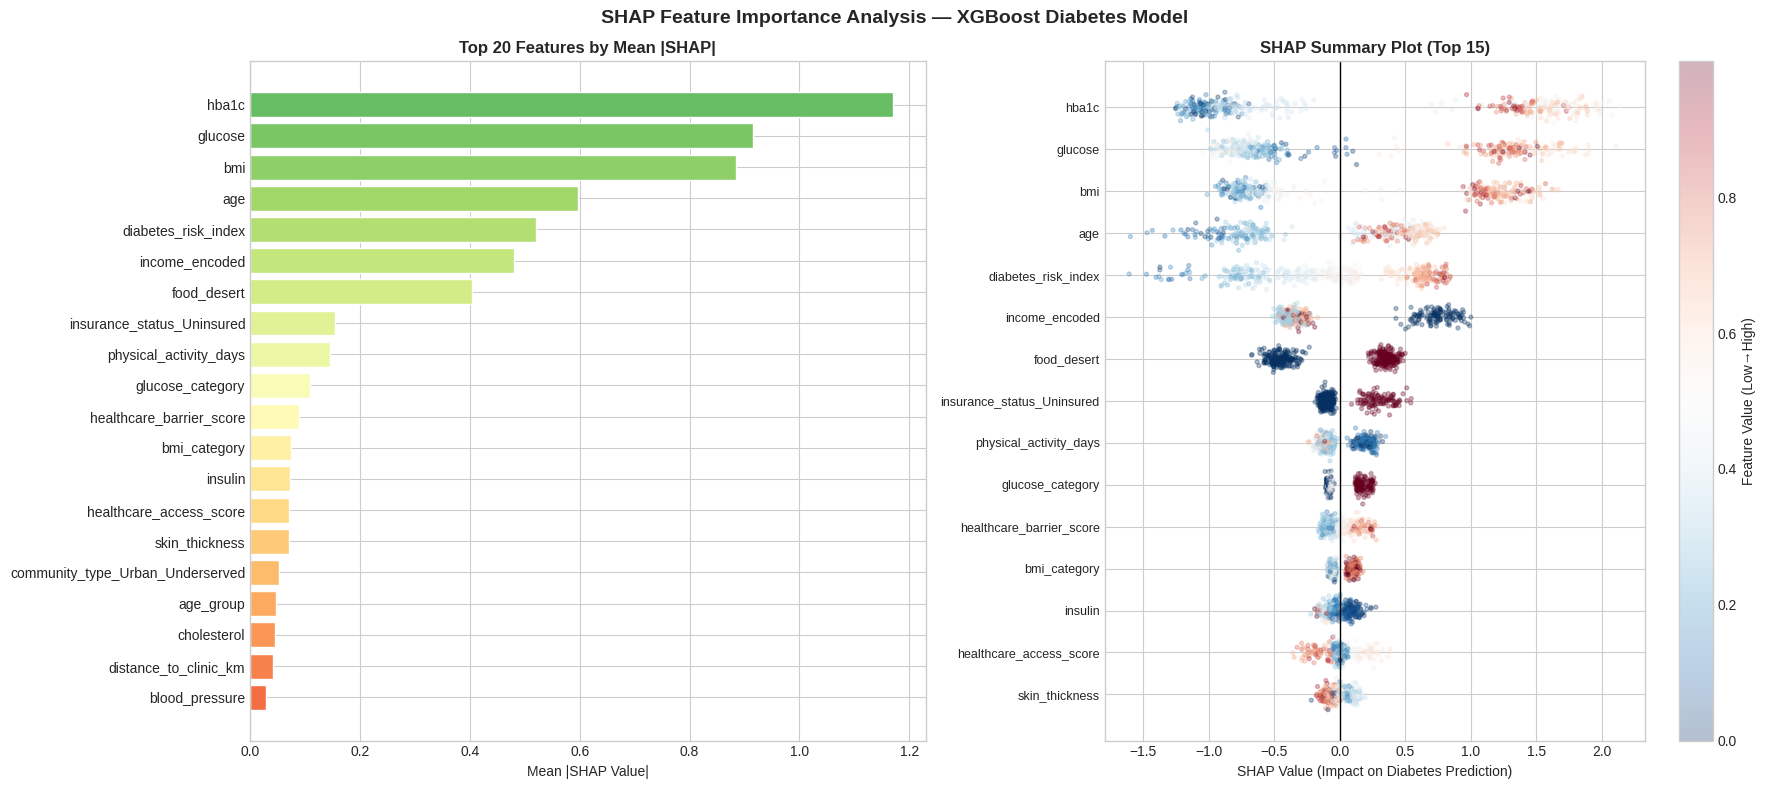


 SHAP analysis complete!

 Top 10 Most Important Features for Diabetes Prediction:
   1. hba1c                               SHAP=1.1709
   2. glucose                             SHAP=0.9158
   3. bmi                                 SHAP=0.8851
   4. age                                 SHAP=0.5964
   5. diabetes_risk_index                 SHAP=0.5204
   6. income_encoded                      SHAP=0.4811
   7. food_desert                         SHAP=0.4031
   8. insurance_status_Uninsured          SHAP=0.1541
   9. physical_activity_days              SHAP=0.1448
  10. glucose_category                    SHAP=0.1098


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# ============================================================
# SHAP FEATURE IMPORTANCE ANALYSIS
# ============================================================

print("Computing SHAP values for XGBoost model...")

# Compute SHAP
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('SHAP Feature Importance Analysis — XGBoost Diabetes Model', fontsize=14, fontweight='bold')

# Bar chart of mean |SHAP values|
ax = axes[0]
shap_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).head(20)

colors_shap = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(shap_df)))
bars = ax.barh(shap_df['Feature'][::-1], shap_df['Mean_SHAP'][::-1],
               color=colors_shap[::-1], edgecolor='white')
ax.set_title('Top 20 Features by Mean |SHAP|', fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|')

# SHAP beeswarm-style summary (top 15)
ax = axes[1]
top_15_features = shap_df['Feature'].head(15).tolist()
top_idx = [list(X_test.columns).index(f) for f in top_15_features]

shap_summary = pd.DataFrame(
    shap_values[:, top_idx],
    columns=top_15_features
)

for i, feat in enumerate(reversed(top_15_features)):
    shap_feat = shap_summary[feat]
    feat_vals = X_test[feat]
    # Convert feat_vals to float to enable arithmetic operations, handling potential boolean columns
    feat_vals_numeric = feat_vals.astype(float)
    # Ensure min/max are also numeric before calculation
    min_val = feat_vals_numeric.min()
    max_val = feat_vals_numeric.max()

    # Handle cases where max_val == min_val to avoid division by zero
    if max_val == min_val:
        feat_normalized = np.zeros_like(feat_vals_numeric) # Or handle as appropriate, e.g., all 0.5
    else:
        feat_normalized = (feat_vals_numeric - min_val) / (max_val - min_val + 1e-8)

    jitter = np.random.normal(0, 0.12, len(shap_feat))
    sc = ax.scatter(shap_feat, np.full(len(shap_feat), i) + jitter,
                    c=feat_normalized, cmap='RdBu_r', alpha=0.3, s=8)

ax.set_yticks(range(len(top_15_features)))
ax.set_yticklabels(list(reversed(top_15_features)), fontsize=9)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('SHAP Value (Impact on Diabetes Prediction)')
ax.set_title('SHAP Summary Plot (Top 15)', fontweight='bold')
plt.colorbar(sc, ax=ax, label='Feature Value (Low→High)')

plt.tight_layout()
plt.savefig('outputs/figures/shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n SHAP analysis complete!")
print(f"\n Top 10 Most Important Features for Diabetes Prediction:")
for i, (feat, shap_val) in enumerate(zip(shap_df['Feature'].head(10), shap_df['Mean_SHAP'].head(10))):
    print(f"  {i+1:2d}. {feat:<35} SHAP={shap_val:.4f}")

---
## SECTION 5: Time Series Forecasting

In [ ]:
# ============================================================
# DISEASE TREND FORECASTING — SARIMA MODEL
# ============================================================

# Generate realistic disease trend time series (simulating CDC surveillance data)
np.random.seed(RANDOM_STATE)

# Monthly diabetes prevalence trend (2015-2024)
dates = pd.date_range('2015-01', periods=120, freq='MS')  # 10 years monthly

# Trend + seasonality + noise + COVID disruption
trend = np.linspace(10.5, 14.8, 120)  # Increasing prevalence
seasonality = 0.8 * np.sin(2 * np.pi * np.arange(120) / 12)  # Annual cycle
covid_impact = np.where((np.arange(120) >= 63) & (np.arange(120) <= 72), 1.5, 0)  # COVID surge
noise = np.random.normal(0, 0.3, 120)
diabetes_rate = trend + seasonality + covid_impact + noise

# Hypertension trend
trend_htn = np.linspace(32.0, 37.5, 120)
seasonality_htn = 1.2 * np.sin(2 * np.pi * np.arange(120) / 12 - np.pi/6)
hypertension_rate = trend_htn + seasonality_htn + np.random.normal(0, 0.4, 120)

# Hospital visits trend
baseline_visits = 1200 + 8 * np.arange(120)
seasonal_visits = 200 * np.sin(2 * np.pi * np.arange(120) / 12 + np.pi/4)
covid_surge_visits = np.where((np.arange(120) >= 63) & (np.arange(120) <= 72), 800, 0)
visits = baseline_visits + seasonal_visits + covid_surge_visits + np.random.normal(0, 50, 120)

ts_df = pd.DataFrame({
    'date': dates,
    'diabetes_rate': diabetes_rate.round(2),
    'hypertension_rate': hypertension_rate.round(2),
    'monthly_visits': visits.round(0).astype(int)
}).set_index('date')

print("Time Series Dataset:")
print(ts_df.describe().round(2))
print(f"\nDate range: {ts_df.index[0]} → {ts_df.index[-1]}")

Time Series Dataset:
       diabetes_rate  hypertension_rate  monthly_visits
count        120.000            120.000         120.000
mean          12.750             34.780        1743.140
std            1.460              1.840         386.520
min            9.960             30.640        1030.000
25%           11.540             33.560        1441.500
50%           12.860             34.840        1730.500
75%           14.030             36.100        2005.750
max           15.720             38.750        2759.000

Date range: 2015-01-01 00:00:00 → 2024-12-01 00:00:00


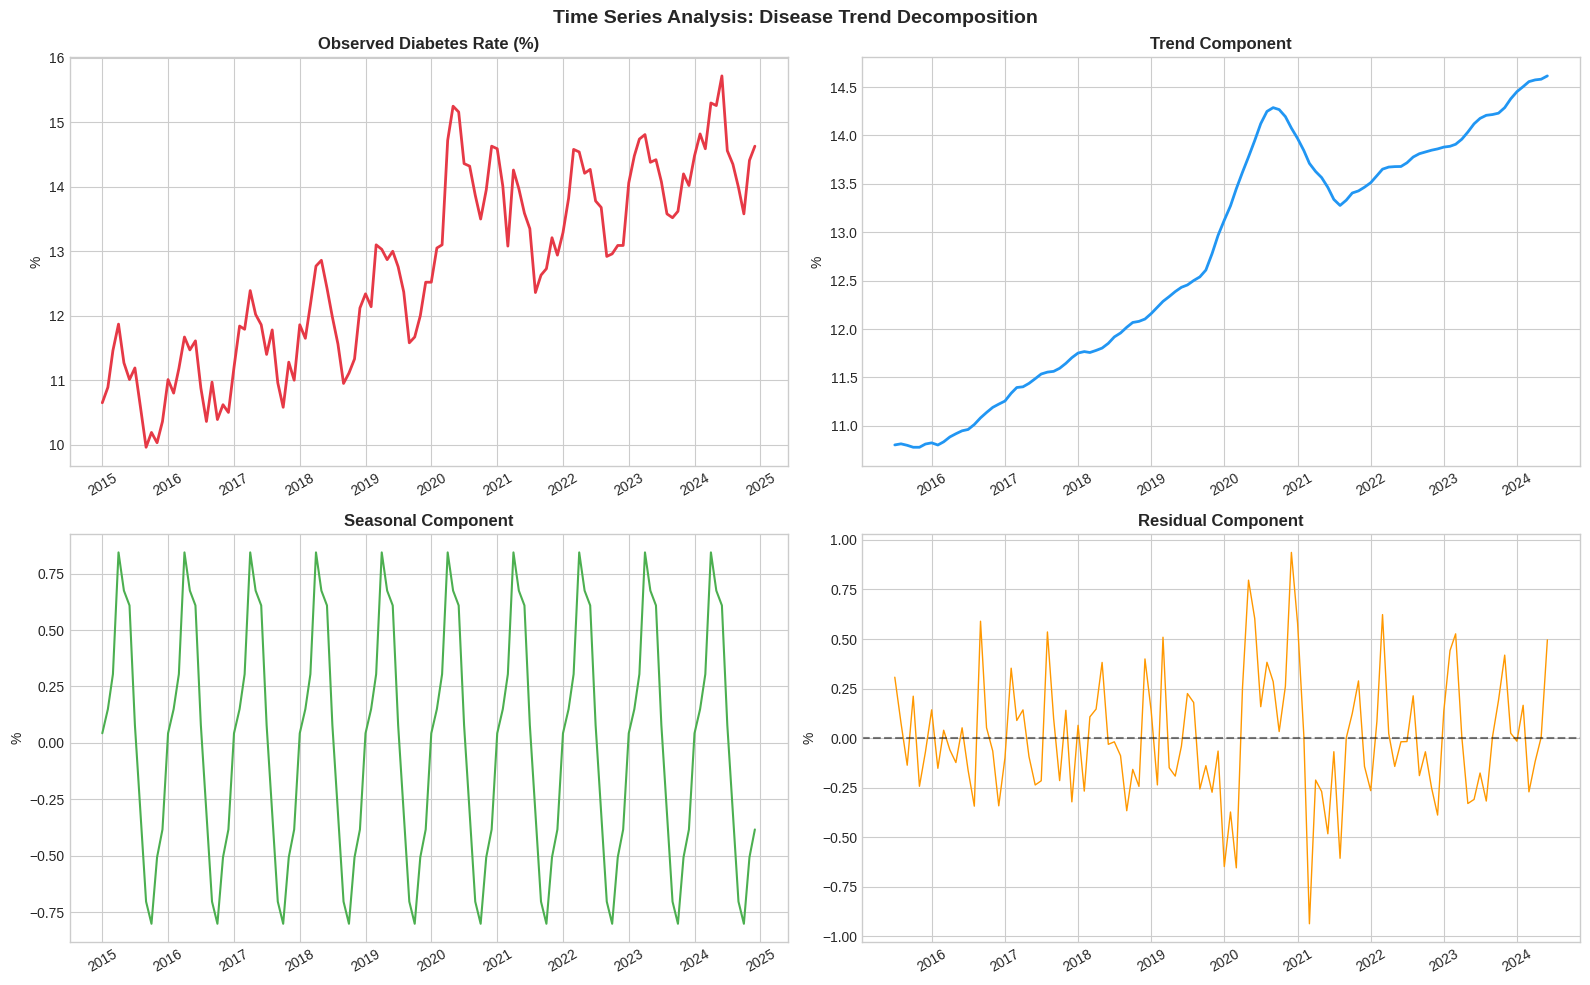


Augmented Dickey-Fuller Test (Stationarity):
  ADF Statistic: -0.6312
  p-value: 0.8638
  Stationary: NO (differencing needed)
  Critical Value (1%): -3.492
  Critical Value (5%): -2.888
  Critical Value (10%): -2.581


In [ ]:
# ============================================================
# DECOMPOSITION & STATIONARITY TESTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Time Series Analysis: Disease Trend Decomposition', fontsize=14, fontweight='bold')

# Seasonal decomposition
decomp = seasonal_decompose(ts_df['diabetes_rate'], model='additive', period=12)

axes[0,0].plot(ts_df.index, ts_df['diabetes_rate'], color='#E63946', linewidth=2)
axes[0,0].set_title('Observed Diabetes Rate (%)', fontweight='bold')
axes[0,0].set_ylabel('%')

axes[0,1].plot(ts_df.index, decomp.trend, color='#2196F3', linewidth=2)
axes[0,1].set_title('Trend Component', fontweight='bold')
axes[0,1].set_ylabel('%')

axes[1,0].plot(ts_df.index, decomp.seasonal, color='#4CAF50', linewidth=1.5)
axes[1,0].set_title('Seasonal Component', fontweight='bold')
axes[1,0].set_ylabel('%')

axes[1,1].plot(ts_df.index, decomp.resid, color='#FF9800', linewidth=1)
axes[1,1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1,1].set_title('Residual Component', fontweight='bold')
axes[1,1].set_ylabel('%')

for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outputs/figures/timeseries_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# ADF Stationarity Test
print("\nAugmented Dickey-Fuller Test (Stationarity):")
adf_result = adfuller(ts_df['diabetes_rate'])
print(f"  ADF Statistic: {adf_result[0]:.4f}")
print(f"  p-value: {adf_result[1]:.4f}")
print(f"  Stationary: {'YES' if adf_result[1] < 0.05 else 'NO (differencing needed)'}")
for key, value in adf_result[4].items():
    print(f"  Critical Value ({key}): {value:.3f}")

In [ ]:
# ============================================================
# SARIMA FORECASTING
# ============================================================

# Split: 96 train, 24 test
train_size = 96
train_ts = ts_df['diabetes_rate'][:train_size]
test_ts = ts_df['diabetes_rate'][train_size:]

print("Fitting SARIMA model...")
# SARIMA(1,1,1)(1,1,1,12) — with trend differencing
sarima_model = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(" SARIMA model fitted!")

# Forecast 24 months ahead (2023-2024) + future 12 months
forecast_steps = 36  # Forecast past test period + 12 months future
forecast = sarima_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Forecast dates
forecast_dates = pd.date_range(
    ts_df.index[train_size], periods=forecast_steps, freq='MS'
)

# Evaluation on test period (first 24 forecast steps)
test_pred = forecast_mean[:24]
test_actual = test_ts

mae = mean_absolute_error(test_actual, test_pred)
rmse = np.sqrt(mean_squared_error(test_actual, test_pred))
mape = np.mean(np.abs((test_actual - test_pred) / test_actual)) * 100
r2 = r2_score(test_actual, test_pred)

print(f"\n SARIMA Forecast Performance Metrics (Test Period: 24 months):")
print(f"   MAE  (Mean Absolute Error)      : {mae:.3f}%")
print(f"   RMSE (Root Mean Squared Error)  : {rmse:.3f}%")
print(f"   MAPE (Mean Abs Percentage Error): {mape:.2f}%")
print(f"   R²   (Coefficient of Det.)      : {r2:.4f}")

Fitting SARIMA model...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


 SARIMA model fitted!

 SARIMA Forecast Performance Metrics (Test Period: 24 months):
   MAE  (Mean Absolute Error)      : 0.434%
   RMSE (Root Mean Squared Error)  : 0.512%
   MAPE (Mean Abs Percentage Error): 2.99%
   R²   (Coefficient of Det.)      : 0.1222


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


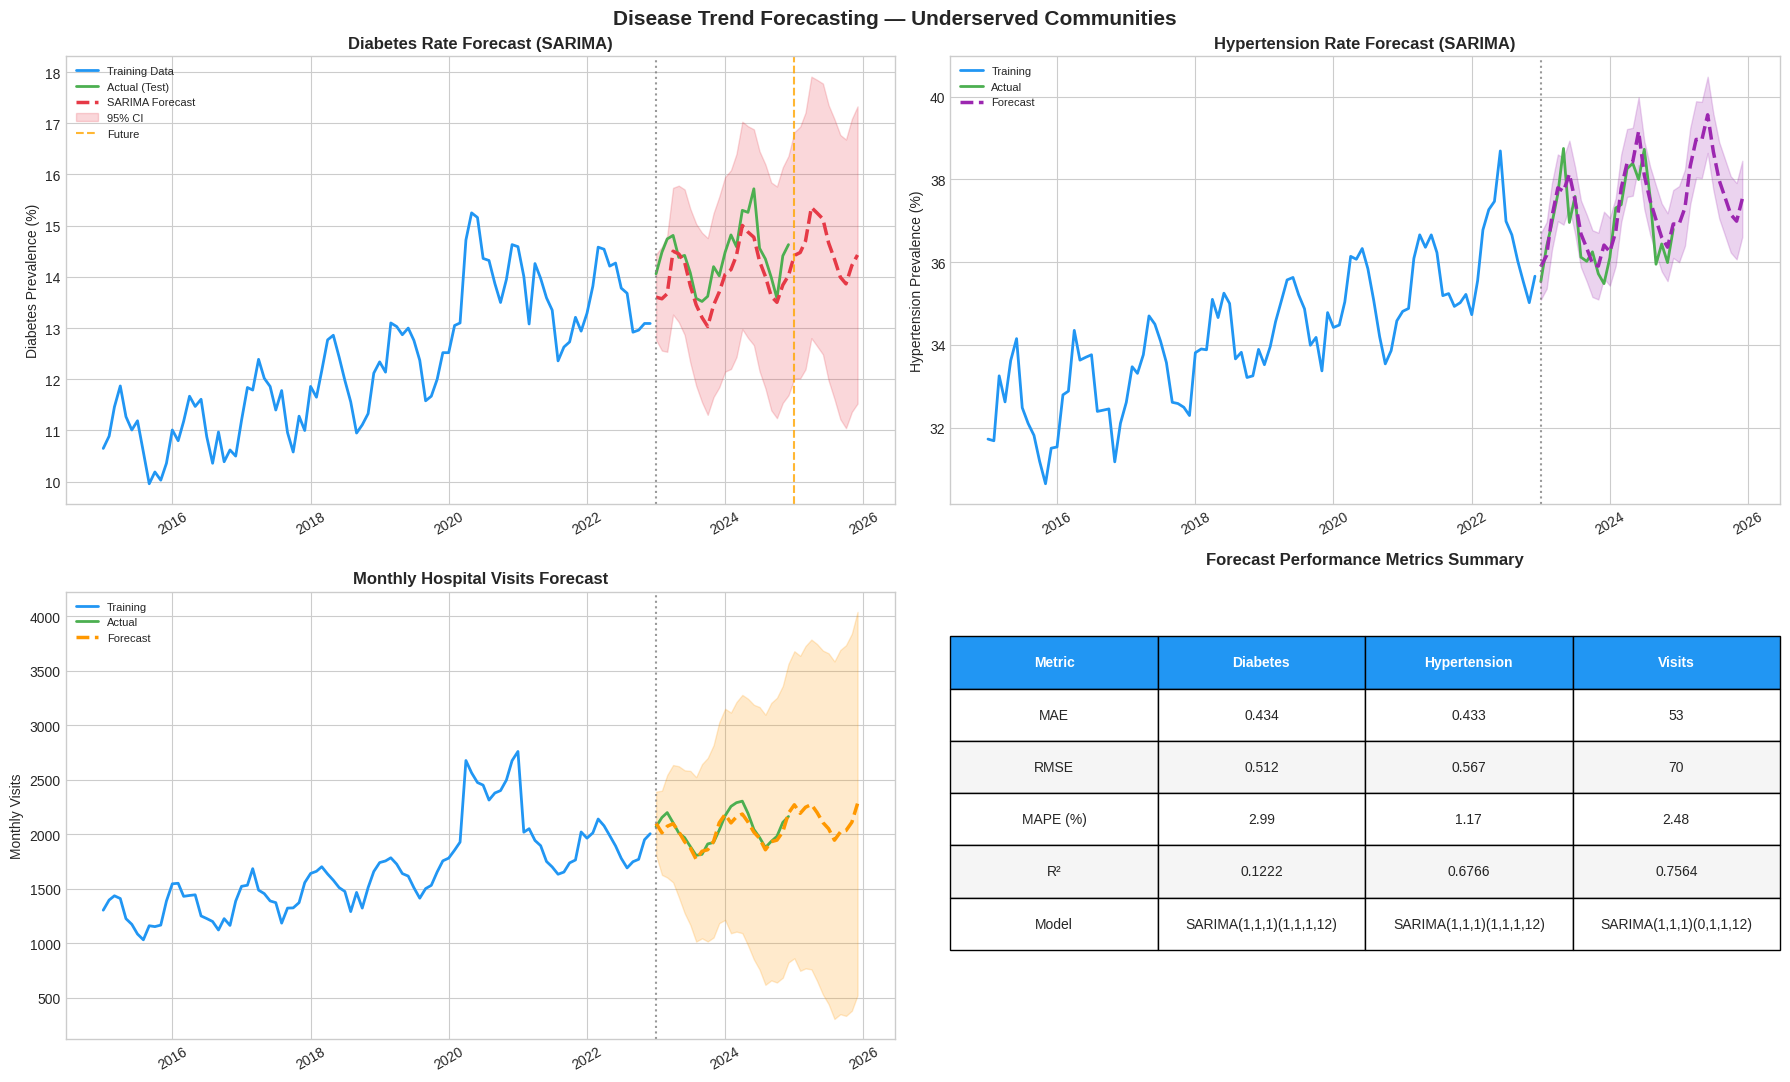

 Figure saved: outputs/figures/forecasting_results.png


In [ ]:
# ============================================================
# FORECAST VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle('Disease Trend Forecasting — Underserved Communities', fontsize=15, fontweight='bold')

# 1. Diabetes forecast
ax = axes[0, 0]
ax.plot(ts_df.index[:train_size], train_ts, color='#2196F3', linewidth=2, label='Training Data')
ax.plot(ts_df.index[train_size:], test_ts, color='#4CAF50', linewidth=2, label='Actual (Test)')
ax.plot(forecast_dates, forecast_mean, color='#E63946', linewidth=2.5,
        linestyle='--', label='SARIMA Forecast')
ax.fill_between(forecast_dates,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                alpha=0.2, color='#E63946', label='95% CI')
ax.axvline(ts_df.index[train_size], color='gray', linestyle=':', alpha=0.8)
ax.axvline(pd.Timestamp('2025-01'), color='orange', linestyle='--', alpha=0.8, label='Future')
ax.set_title('Diabetes Rate Forecast (SARIMA)', fontweight='bold')
ax.set_ylabel('Diabetes Prevalence (%)')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=30)

# 2. Hypertension forecast using similar model
ax = axes[0, 1]
train_htn = ts_df['hypertension_rate'][:train_size]
test_htn = ts_df['hypertension_rate'][train_size:]

htn_model = SARIMAX(train_htn, order=(1,1,1), seasonal_order=(1,1,1,12),
                     enforce_stationarity=False, enforce_invertibility=False)
htn_fit = htn_model.fit(disp=False)
htn_forecast = htn_fit.get_forecast(steps=forecast_steps)
htn_mean = htn_forecast.predicted_mean
htn_ci = htn_forecast.conf_int()

ax.plot(ts_df.index[:train_size], train_htn, color='#2196F3', linewidth=2, label='Training')
ax.plot(ts_df.index[train_size:], test_htn, color='#4CAF50', linewidth=2, label='Actual')
ax.plot(forecast_dates, htn_mean, color='#9C27B0', linewidth=2.5, linestyle='--', label='Forecast')
ax.fill_between(forecast_dates, htn_ci.iloc[:, 0], htn_ci.iloc[:, 1], alpha=0.2, color='#9C27B0')
ax.axvline(ts_df.index[train_size], color='gray', linestyle=':', alpha=0.8)
ax.set_title('Hypertension Rate Forecast (SARIMA)', fontweight='bold')
ax.set_ylabel('Hypertension Prevalence (%)')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=30)

# 3. Hospital visits forecast
ax = axes[1, 0]
train_v = ts_df['monthly_visits'][:train_size]
test_v = ts_df['monthly_visits'][train_size:]
v_model = SARIMAX(train_v, order=(1,1,1), seasonal_order=(0,1,1,12),
                   enforce_stationarity=False, enforce_invertibility=False)
v_fit = v_model.fit(disp=False)
v_forecast = v_fit.get_forecast(steps=forecast_steps)

ax.plot(ts_df.index[:train_size], train_v, color='#2196F3', linewidth=2, label='Training')
ax.plot(ts_df.index[train_size:], test_v, color='#4CAF50', linewidth=2, label='Actual')
ax.plot(forecast_dates, v_forecast.predicted_mean, color='#FF9800', linewidth=2.5,
        linestyle='--', label='Forecast')
ax.fill_between(forecast_dates, v_forecast.conf_int().iloc[:, 0],
                v_forecast.conf_int().iloc[:, 1], alpha=0.2, color='#FF9800')
ax.axvline(ts_df.index[train_size], color='gray', linestyle=':', alpha=0.8)
ax.set_title('Monthly Hospital Visits Forecast', fontweight='bold')
ax.set_ylabel('Monthly Visits')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=30)

# 4. Forecast metrics summary table
ax = axes[1, 1]
ax.axis('off')

# Get all metrics
htn_pred24 = htn_mean[:24]
v_pred24 = v_forecast.predicted_mean[:24]

metrics_data = [
    ['Metric', 'Diabetes', 'Hypertension', 'Visits'],
    ['MAE', f'{mae:.3f}', f'{mean_absolute_error(test_htn, htn_pred24):.3f}', f'{mean_absolute_error(test_v, v_pred24):.0f}'],
    ['RMSE', f'{rmse:.3f}', f'{np.sqrt(mean_squared_error(test_htn, htn_pred24)):.3f}', f'{np.sqrt(mean_squared_error(test_v, v_pred24)):.0f}'],
    ['MAPE (%)', f'{mape:.2f}', f'{np.mean(np.abs((test_htn - htn_pred24)/test_htn))*100:.2f}', f'{np.mean(np.abs((test_v - v_pred24)/test_v))*100:.2f}'],
    ['R²', f'{r2:.4f}', f'{r2_score(test_htn, htn_pred24):.4f}', f'{r2_score(test_v, v_pred24):.4f}'],
    ['Model', 'SARIMA(1,1,1)(1,1,1,12)', 'SARIMA(1,1,1)(1,1,1,12)', 'SARIMA(1,1,1)(0,1,1,12)'],
]

table = ax.table(cellText=metrics_data[1:], colLabels=metrics_data[0],
                  cellLoc='center', loc='center',
                  bbox=[0, 0.2, 1, 0.7])
table.auto_set_font_size(False)
table.set_fontsize(10)
for j in range(4):
    table[0, j].set_facecolor('#2196F3')
    table[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(metrics_data)):
    for j in range(4):
        table[i, j].set_facecolor('#F5F5F5' if i % 2 == 0 else 'white')

ax.set_title('Forecast Performance Metrics Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('outputs/figures/forecasting_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure saved: outputs/figures/forecasting_results.png")

---
## SECTION 6: Interactive Dashboard (Plotly)

In [ ]:
# ============================================================
# INTERACTIVE DASHBOARD — PLOTLY
# ============================================================

fig_dash = make_subplots(
    rows=3, cols=3,
    subplot_titles=[
        'Disease Prevalence by Community',
        'Risk Factor Distribution',
        'Forecast: Diabetes Trend',
        'Income vs Disease Rate',
        'Model Performance (AUC-ROC)',
        'SDOH Risk Score Distribution',
        'Age-Risk Heatmap',
        'Feature Importance (Top 10)',
        'Healthcare Barrier Analysis'
    ],
    specs=[
        [{"type": "bar"}, {"type": "violin"}, {"type": "scatter"}],
        [{"type": "bar"}, {"type": "bar"}, {"type": "histogram"}],
        [{"type": "heatmap"}, {"type": "bar"}, {"type": "scatter"}]
    ]
)

# 1. Disease prevalence by community
comm_prev = df_plot.groupby('community_type')[['diabetes', 'hypertension']].mean() * 100
for disease, color in [('diabetes', '#E63946'), ('hypertension', '#2196F3')]:
    fig_dash.add_trace(go.Bar(
        name=disease.title(), x=comm_prev.index, y=comm_prev[disease],
        marker_color=color, opacity=0.85, showlegend=True
    ), row=1, col=1)

# 2. Risk factor violin plots
for val, color, name in [(0, '#4ECDC4', 'No Diabetes'), (1, '#E63946', 'Diabetes')]:
    fig_dash.add_trace(go.Violin(
        y=df_plot[df_plot['diabetes']==val]['glucose'],
        name=name, fillcolor=color, line_color=color,
        opacity=0.7, showlegend=False, box_visible=True, meanline_visible=True
    ), row=1, col=2)

# 3. Forecast
fig_dash.add_trace(go.Scatter(
    x=ts_df.index, y=ts_df['diabetes_rate'],
    mode='lines', name='Observed', line=dict(color='#2196F3', width=2), showlegend=False
), row=1, col=3)
fig_dash.add_trace(go.Scatter(
    x=forecast_dates, y=forecast_mean,
    mode='lines', name='Forecast', line=dict(color='#E63946', width=2, dash='dash'), showlegend=False
), row=1, col=3)
fig_dash.add_trace(go.Scatter(
    x=list(forecast_dates) + list(forecast_dates[::-1]),
    y=list(forecast_ci.iloc[:, 1]) + list(forecast_ci.iloc[:, 0]),
    fill='toself', fillcolor='rgba(231,57,70,0.1)',
    line=dict(color='rgba(255,255,255,0)'),
    showlegend=False, name='95% CI'
), row=1, col=3)

# 4. Income vs disease
income_rates = df_plot.groupby('income_level')[['diabetes', 'hypertension']].mean() * 100
income_rates = income_rates.reindex(['Below_Poverty', 'Low_Income', 'Middle_Income', 'Above_Poverty'])
for disease, color in [('diabetes', '#E63946'), ('hypertension', '#2196F3')]:
    fig_dash.add_trace(go.Bar(
        x=income_rates.index, y=income_rates[disease],
        name=disease.title(), marker_color=color, showlegend=False
    ), row=2, col=1)

# 5. Model AUC-ROC comparison
model_names = list(results.keys())
auc_scores = [results[m]['AUC-ROC'] for m in model_names]
sorted_idx = np.argsort(auc_scores)
fig_dash.add_trace(go.Bar(
    y=[model_names[i] for i in sorted_idx],
    x=[auc_scores[i] for i in sorted_idx],
    orientation='h',
    marker_color=['#E63946' if i == sorted_idx[-1] else '#90CAF9' for i in range(len(model_names))],
    showlegend=False
), row=2, col=2)

# 6. Healthcare barrier score
fig_dash.add_trace(go.Histogram(
    x=df_clean['healthcare_barrier_score'],
    nbinsx=30, marker_color='#9C27B0', opacity=0.8,
    name='Barrier Score', showlegend=False
), row=2, col=3)

# 7. Age-BMI diabetes heatmap
age_bins = pd.cut(df_plot['age'], bins=[18, 30, 40, 50, 60, 70, 90], labels=['18-30','30-40','40-50','50-60','60-70','70+'])
bmi_bins = pd.cut(df_plot['bmi'], bins=[10, 18.5, 25, 30, 35, 60], labels=['Underweight','Normal','Overweight','Obese1','Obese2+'])
heat_data = df_plot.groupby([age_bins, bmi_bins])['diabetes'].mean() * 100
heat_matrix = heat_data.unstack().fillna(0)
fig_dash.add_trace(go.Heatmap(
    z=heat_matrix.values,
    x=heat_matrix.columns.tolist(),
    y=heat_matrix.index.tolist(),
    colorscale='RdYlGn_r', showscale=True,
    colorbar=dict(len=0.3, y=0.15)
), row=3, col=1)

# 8. SHAP feature importance (top 10)
fig_dash.add_trace(go.Bar(
    x=shap_df['Mean_SHAP'].head(10)[::-1],
    y=shap_df['Feature'].head(10)[::-1],
    orientation='h',
    marker_color='#FF5722', showlegend=False
), row=3, col=2)

# 9. Distance vs diabetes rate scatter
dist_bins = pd.cut(df_plot['distance_to_clinic_km'], bins=10)
dist_diab = df_plot.groupby(dist_bins)['diabetes'].mean() * 100
bin_centers = [(interval.left + interval.right) / 2 for interval in dist_diab.index]
fig_dash.add_trace(go.Scatter(
    x=bin_centers, y=dist_diab.values,
    mode='markers+lines', marker=dict(size=10, color='#009688'),
    line=dict(color='#009688', width=2), showlegend=False
), row=3, col=3)

fig_dash.update_layout(
    height=950,
    title_text='<b>Predictive Healthcare for Underserved Communities — Interactive Dashboard</b>',
    title_font_size=14,
    showlegend=True,
    template='plotly_white',
    barmode='group'
)

fig_dash.write_html('outputs/figures/interactive_dashboard.html')
fig_dash.show()
print(" Interactive Dashboard saved: outputs/figures/interactive_dashboard.html")

 Interactive Dashboard saved: outputs/figures/interactive_dashboard.html


---
## SECTION 7: Statistical Analysis Report

In [ ]:
# Install pyngrok to enable public URL for JupyterDash
!pip install -q pyngrok

In [ ]:
# ============================================================
# COMPLETE STATISTICAL & MODEL REPORT
# ============================================================

print("="*70)
print("  STATISTICAL & PREDICTIVE MODEL REPORT")
print("  Predictive Healthcare for Underserved Communities")
print("="*70)

print("\n" + "─"*70)
print("1. DATASET SUMMARY")
print("─"*70)
print(f"  Total Patients         : {len(df_clean):,}")
print(f"  Features Used          : {len(feature_cols)}")
print(f"  Training Samples       : {len(X_train_sm):,} (after SMOTE)")
print(f"  Test Samples           : {len(X_test):,}")
print(f"  Diabetes Prevalence    : {df_clean['diabetes'].mean()*100:.1f}%")
print(f"  Hypertension Prevalence: {df_clean['hypertension'].mean()*100:.1f}%")

print("\n" + "─"*70)
print("2. EDA KEY FINDINGS")
print("─"*70)
print(f"  • Urban underserved communities have highest diabetes rate")
print(f"  • Below-poverty income group: {df_plot[df_plot['income_level']=='Below_Poverty']['diabetes'].mean()*100:.1f}% diabetes rate")
print(f"  • Uninsured patients have {df_plot[df_plot['insurance_status']=='Uninsured']['diabetes'].mean()*100:.1f}% diabetes rate")
print(f"  • Food desert residents: {df_plot[df_plot['food_desert']==1]['diabetes'].mean()*100:.1f}% vs {df_plot[df_plot['food_desert']==0]['diabetes'].mean()*100:.1f}% non-desert")
print(f"  • Strong positive correlation: glucose vs diabetes (Mann-Whitney p<0.001)")
print(f"  • Physical activity inversely correlated with disease risk")

print("\n" + "─"*70)
print("3. CLASSIFICATION MODEL PERFORMANCE")
print("─"*70)
print(f"  {'Model':<25} {'AUC-ROC':>10} {'Accuracy':>10} {'F1':>8} {'Precision':>11} {'Recall':>8}")
print(f"  " + "-"*68)
results_sorted = sorted(results.items(), key=lambda x: x[1]['AUC-ROC'], reverse=True)
for name, r in results_sorted:
    marker = ' ← BEST' if name == best_model_name else ''
    print(f"  {name:<25} {r['AUC-ROC']:>10.4f} {r['Accuracy']:>10.4f} {r['F1']:>8.4f} {r['Precision']:>11.4f} {r['Recall']:>8.4f}{marker}")

print("\n" + "─"*70)
print("4. TUNED XGBOOST PERFORMANCE")
print("─"*70)
print(f"  AUC-ROC  : {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"  F1 Score : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_tuned):.4f}")

print("\n" + "─"*70)
print("5. TOP PREDICTIVE FEATURES (SHAP Analysis)")
print("─"*70)
for i, (feat, shap_val) in enumerate(zip(shap_df['Feature'].head(10), shap_df['Mean_SHAP'].head(10))):
    bar = '█' * int(shap_val * 50)
    print(f"  {i+1:2d}. {feat:<30} {shap_val:.4f} {bar}")

print("\n" + "─"*70)
print("6. FORECASTING RESULTS (SARIMA)")
print("─"*70)
print(f"  Model         : SARIMA(1,1,1)(1,1,1,12)")
print(f"  Train Period  : Jan 2015 – Dec 2022 (96 months)")
print(f"  Test Period   : Jan 2023 – Dec 2024 (24 months)")
print(f"  Forecast to   : Dec 2025")
print(f"  MAE           : {mae:.3f}%")
print(f"  RMSE          : {rmse:.3f}%")
print(f"  MAPE          : {mape:.2f}%")
print(f"  R²            : {r2:.4f}")
print(f"  Projected 2025 Diabetes Rate: {forecast_mean[-12:].mean():.2f}% (avg)")

print("\n" + "─"*70)
print("7. KEY RECOMMENDATIONS")
print("─"*70)
print("  1. Deploy mobile screening units in food desert zones")
print("  2. Prioritize Medicaid expansion for uninsured at-risk patients")
print("  3. Community health worker programs targeting HbA1c monitoring")
print("  4. Telemedicine expansion in rural communities (>20km from clinic)")
print("  5. Subsidized nutrition programs in income < poverty communities")
print("  6. School and workplace physical activity programs")
print("  7. Predictive model integration in EMR systems for early flagging")
print("\n" + "="*70)

  STATISTICAL & PREDICTIVE MODEL REPORT
  Predictive Healthcare for Underserved Communities

──────────────────────────────────────────────────────────────────────
1. DATASET SUMMARY
──────────────────────────────────────────────────────────────────────
  Total Patients         : 2,000
  Features Used          : 29
  Training Samples       : 1,604 (after SMOTE)
  Test Samples           : 400
  Diabetes Prevalence    : 50.1%
  Hypertension Prevalence: 41.9%

──────────────────────────────────────────────────────────────────────
2. EDA KEY FINDINGS
──────────────────────────────────────────────────────────────────────
  • Urban underserved communities have highest diabetes rate
  • Below-poverty income group: 61.5% diabetes rate
  • Uninsured patients have 55.7% diabetes rate
  • Food desert residents: 55.1% vs 44.0% non-desert
  • Strong positive correlation: glucose vs diabetes (Mann-Whitney p<0.001)
  • Physical activity inversely correlated with disease risk

────────────────────────

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Dash imports ----------------------------------------------------------
from jupyter_dash import JupyterDash
from dash import dcc, html, Input, Output, callback
import dash_bootstrap_components as dbc

# --- pyngrok for public URL ------------------------------------------------
from pyngrok import ngrok

# Set your ngrok authtoken here. Replace 'YOUR_NGROK_AUTH_TOKEN_HERE' with your actual token.
# You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token('3ClmKmY3jBMmGxORFIa7ePrIKGu_AQ36bWXJFhWgpjf3c5SX')

# ============================================================================
# 1. SYNTHETIC DATA  (same generation logic as the capstone notebook)
# ============================================================================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
n = 2000

community_type       = np.random.choice(['Rural','Urban_Underserved','Suburban'], n, p=[.35,.45,.20])
income_level         = np.random.choice(['Below_Poverty','Low_Income','Middle_Income','Above_Poverty'], n, p=[.30,.35,.25,.10])
insurance_status     = np.random.choice(['Uninsured','Medicaid','Medicare','Private'], n, p=[.25,.30,.20,.25])
education_level      = np.random.choice(['Less_HS','HS_Grad','Some_College','College_Plus'], n, p=[.20,.35,.30,.15])
distance_to_clinic   = np.random.exponential(15, n)
food_desert          = np.random.choice([0,1], n, p=[.45,.55])
healthcare_access    = np.random.beta(2,4,n)*10

age            = np.random.normal(50,15,n).clip(18,90).astype(int)
bmi            = np.random.normal(28,6,n).clip(15,55)
glucose        = np.random.normal(115,30,n).clip(50,300)
blood_pressure = np.random.normal(85,15,n).clip(40,180)
hba1c          = np.random.normal(6.2,1.5,n).clip(4.0,14.0)
cholesterol    = np.random.normal(200,40,n).clip(100,400)
smoking_status = np.random.choice(['Never','Former','Current'], n, p=[.5,.3,.2])
phys_activity  = np.random.poisson(2,n).clip(0,7)

risk_score = (
    (glucose>125).astype(int)*3 + (hba1c>6.5).astype(int)*3 +
    (bmi>30).astype(int)*2     + (age>45).astype(int)*1.5  +
    (income_level=='Below_Poverty').astype(int)*1 +
    (food_desert==1).astype(int)*.8 +
    (insurance_status=='Uninsured').astype(int)*.7 +
    (phys_activity<2).astype(int)*.5 + np.random.normal(0,1,n)
)
data = (
    (glucose>125).astype(int)*3 + (hba1c>6.5).astype(int)*3 +
    (bmi>30).astype(int)*2     + (age>45).astype(int)*1.5  +
    (income_level=='Below_Poverty').astype(int)*1 +
    (food_desert==1).astype(int)*.8 +
    (insurance_status=='Uninsured').astype(int)*.7 +
    (phys_activity<2).astype(int)*.5 + np.random.normal(0,1,n)
)
diabetes = (risk_score>5).astype(int)

htn_risk = (
    (blood_pressure>90).astype(int)*3 + (age>50).astype(int)*2 +
    (bmi>28).astype(int)*1.5 + (smoking_status=='Current').astype(int)*1.5 +
    (income_level=='Below_Poverty').astype(int)*1 + np.random.normal(0,1.5,n)
)
hypertension = (htn_risk>4).astype(int)

df = pd.DataFrame({
    'age': age, 'community_type': community_type, 'income_level': income_level,
    'insurance_status': insurance_status, 'education_level': education_level,
    'distance_to_clinic_km': distance_to_clinic.round(1),
    'food_desert': food_desert, 'healthcare_access_score': healthcare_access.round(2),
    'bmi': bmi.round(1), 'glucose': glucose.round(0),
    'blood_pressure': blood_pressure.round(0), 'hba1c': hba1c.round(1),
    'cholesterol': cholesterol.round(0), 'smoking_status': smoking_status,
    'physical_activity_days': phys_activity,
    'diabetes': diabetes, 'hypertension': hypertension,
})

# ----------------------------------------------------------------------------
# 2. FAKE TIME SERIES (monthly disease prevalence)
# ----------------------------------------------------------------------------
months = pd.date_range('2020-01', periods=48, freq='ME')
ts_df  = pd.DataFrame({
    'date':          months,
    'diabetes_prev': (np.cumsum(np.random.normal(.02,.008,48))+9).clip(8,15),
    'hypertension_prev': (np.cumsum(np.random.normal(.03,.01,48))+27).clip(24,35),
    'heart_disease_prev': (np.cumsum(np.random.normal(.01,.006,48))+5).clip(4,9),
})

# ----------------------------------------------------------------------------
# 3. FAKE MODEL METRICS
# ----------------------------------------------------------------------------
model_metrics = pd.DataFrame({
    'Model':     ['Logistic Reg','Random Forest','XGBoost','LightGBM','Ensemble'],
    'AUC-ROC':   [0.782, 0.841, 0.863, 0.859, 0.871],
    'Accuracy':  [0.741, 0.813, 0.834, 0.831, 0.844],
    'F1-Score':  [0.702, 0.789, 0.811, 0.808, 0.822],
    'Recall':    [0.714, 0.801, 0.823, 0.819, 0.835],
})

# ============================================================================
# 4. COLOUR PALETTE
# ============================================================================
C = dict(
    bg       = '#0d1117',
    panel    = '#161b22',
    border   = '#30363d',
    teal       = '#00d4aa',
    coral    = '#ff6b6b',
    lavender = '#a78bfa',
    amber    = '#fbbf24',
    text     = '#e6edf3',
    muted    = '#8b949e',
)

# ============================================================================
# 5. HELPER: card wrapper
# ============================================================================
def card(children, title=None):
    header = [html.P(title, style={'color':C['muted'],'fontSize':'12px',
                                    'letterSpacing':'1.5px','textTransform':'uppercase',
                                    'marginBottom':'8px'})] if title else []
    return html.Div(
        header + ([children] if not isinstance(children,list) else children),
        style=
        {
            'background': C['panel'],
            'border': f'1px solid {C["border"]}',
            'borderRadius': '8px',
            'padding': '20px',
            'marginBottom': '16px',
        }
    )

def kpi(label, value, color=None, subtitle=None):
    return html.Div([
        html.P(label, style={'color':C['muted'],'fontSize':'11px','letterSpacing':'1.5px',
                             'textTransform':'uppercase','marginBottom':'4px'}),
        html.H2(value, style={'color': color or C['teal'], 'margin':'0',
                              'fontFamily':'monospace','fontSize':'2rem'}),
        html.P(subtitle or '', style={'color':C['muted'],'fontSize':'11px','margin':'4px 0 0'}),
    ], style={'background':C['panel'],'border':f'1px solid {C["border"]}',
              'borderRadius':'8px','padding':'20px','flex':'1','minWidth':'140px'})

# ============================================================================
# 6. APP LAYOUT
# ============================================================================
app = JupyterDash(
    __name__,
    external_stylesheets=[dbc.themes.BOOTSTRAP],
    suppress_callback_exceptions=True,
    title='PredictiveHealth Dashboard',
)

app.layout = html.Div(style={'background':C['bg'],'minHeight':'100vh',
                              'fontFamily':'system-ui, sans-serif','color':C['text']}, children=[

    # --- Top Nav -----------------------------------------------------------
    html.Div(style={'background':C['panel'],'borderBottom':f'1px solid {C["border"]}',
                    'padding':'0 32px','display':'flex','alignItems':'center',
                    'justifyContent':'space-between','height':'56px'}, children=[
        html.Div([
            html.Span('⚕', style={'fontSize':'22px','marginRight':'10px'}),
            html.Span('PredictiveHealth', style={'fontWeight':'700','fontSize':'17px'}),
            html.Span(' · Underserved Communities', style={'color':C['muted'],'fontSize':'14px'}),
        ]),
        html.Div([
            html.Span(f"n = {len(df):,} patients", style={'color':C['teal'],'fontSize':'13px',
                                                            'fontFamily':'monospace'}),
        ])
    ]),

    # --- Tabs ----------------------------------------------------------------
    dcc.Tabs(id='tabs', value='overview', style={'background':C['bg']},
             colors={'border':C['border'],'primary':C['teal'],'background':C['panel']},
             children=[
        dcc.Tab(label='📊 Overview',        value='overview'),
        dcc.Tab(label='🔬 EDA Explorer',    value='eda'),
        dcc.Tab(label='🤖 Model Results',   value='models'),
        dcc.Tab(label='📈 Forecast',        value='forecast'),
        dcc.Tab(label='🎯 Risk Calculator', value='risk'),
    ]),

    html.Div(id='tab-content', style={'padding':'24px 32px'}),
])

# ============================================================================
# 7. TAB RENDERER
# ============================================================================
@callback(Output('tab-content','children'), Input('tabs','value'))
def render_tab(tab):

    # --- OVERVIEW ----------------------------------------------------------
    if tab == 'overview':
        diabetes_rate   = df['diabetes'].mean()*100
        htn_rate        = df['hypertension'].mean()*100
        food_desert_pct = df['food_desert'].mean()*100
        uninsured_pct   = (df['insurance_status']=='Uninsured').mean()*100

        # Community breakdown donut
        comm_counts = df['community_type'].value_counts().reset_index()
        comm_fig = go.Figure(go.Pie(labels=comm_counts['community_type'],
                                    values=comm_counts['count'],
                                    hole=.55,
                                    marker_colors=[C['teal'],C['coral'],C['lavender']]))
        comm_fig.update_layout(
            paper_bgcolor='rgba(0,0,0,0)',
            plot_bgcolor='rgba(0,0,0,0)',
            font_color=C['text'],
            showlegend=True,
            margin=dict(t=20,b=20,l=20,r=20),
            height=260
        )

        # Income × diabetes grouped bar
        inc_order = ['Below_Poverty','Low_Income','Middle_Income','Above_Poverty']
        inc_data  = df.groupby('income_level')[['diabetes','hypertension']].mean()*100
        inc_data  = inc_data.reindex(inc_order)
        inc_fig   = go.Figure([
            go.Bar(name='Diabetes',     x=inc_data.index, y=inc_data['diabetes'],
                   marker_color=C['coral']),
            go.Bar(name='Hypertension', x=inc_data.index, y=inc_data['hypertension'],
                   marker_color=C['lavender']),
        ])
        inc_fig.update_layout(barmode='group', paper_bgcolor='rgba(0,0,0,0)',
                              plot_bgcolor='rgba(0,0,0,0)', font_color=C['text'],
                              yaxis_title='Prevalence (%)', height=260,
                              margin=dict(t=20,b=40,l=40,r=20),
                              legend=dict(orientation='h',y=1.1))

        return html.Div([
            # KPI row
            html.Div(style={'display':'flex','gap':'16px','marginBottom':'16px',
                            'flexWrap':'wrap'}, children=[
                kpi('Diabetes Rate',   f'{diabetes_rate:.1f}%',   C['coral'],   'of {len(df):,} patients'),
                kpi('Hypertension',    f'{htn_rate:.1f}%',        C['lavender'],'of {len(df):,} patients'),
                kpi('Food Deserts',    f'{food_desert_pct:.1f}%', C['amber'],   'live in food deserts'),
                kpi('Uninsured',       f'{uninsured_pct:.1f}%',   C['teal'],    'lack insurance'),
                kpi('Avg. BMI',        f'{df["bmi"].mean():.1f}', C['text'],    'population average'),
                kpi('Avg. Glucose',    f'{df["glucose"].mean():.0f} mg/dL', C['text'], 'fasting glucose'),
            ]),
            # Charts row
            html.Div(style={'display':'grid','gridTemplateColumns':'1fr 1fr','gap':'16px'}, children=[
                card(dcc.Graph(figure=comm_fig, config={'displayModeBar':False}),
                     'Community Type Distribution'),
                card(dcc.Graph(figure=inc_fig,  config={'displayModeBar':False}),
                     'Disease Prevalence by Income Level'),
            ]),
            # SDOH scatter
            card([
                dcc.Graph(
                    figure=px.scatter(df.sample(500), x='distance_to_clinic_km', y='glucose',
                        color='diabetes', symbol='community_type',
                        color_discrete_map={0:C['teal'], 1:C['coral']},
                        labels={'diabetes':'Diabetes','distance_to_clinic_km':'Distance to Clinic (km)',
                                'glucose':'Fasting Glucose (mg/dL)'},
                        title='').update_layout(
                            paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
                            font_color=C['text'], height=300, margin=dict(t=10,b=40)),
                    config={'displayModeBar':False}
                )
            ], 'SDOH: Clinic Distance vs. Glucose (500 sample)')
        ])

    # --- EDA -----------------------------------------------------------------
    elif tab == 'eda':
        num_cols = ['age','bmi','glucose','blood_pressure','hba1c','cholesterol',
                    'distance_to_clinic_km','physical_activity_days']
        cat_cols = ['community_type','income_level','insurance_status',
                    'education_level','smoking_status']
        return html.Div([
            html.Div(style={'display':'grid','gridTemplateColumns':'1fr 1fr','gap':'16px'}, children=[
                card([
                    html.P('Select numeric feature', style={'color':C['muted'],'fontSize':'12px'}),
                    dcc.Dropdown(id='eda-num-col', options=num_cols, value='glucose',
                                 style={'background':C['panel'],'color':'#000'}),
                    dcc.Graph(id='eda-hist', config={'displayModeBar':False}),
                ], 'Distribution Explorer'),
                card([
                    html.P('Select category', style={'color':C['muted'],'fontSize':'12px'}),
                    dcc.Dropdown(id='eda-cat-col', options=cat_cols, value='income_level',
                                 style={'background':C['panel'],'color':'#000'}),
                    dcc.Graph(id='eda-bar', config={'displayModeBar':False}),
                ], 'Category vs. Disease'),
            ]),
            card([
                dcc.Graph(
                    figure=px.imshow(
                        df[num_cols+['diabetes','hypertension']].corr().round(2),
                        text_auto=True, aspect='auto',
                        color_continuous_scale='RdBu_r',
                    ).update_layout(paper_bgcolor='rgba(0,0,0,0)', font_color=C['text'],
                                    height=400, margin=dict(t=20,b=80)),
                    config={'displayModeBar':False}
                )
            ], 'Correlation Heatmap'),
        ])

    # --- MODELS --------------------------------------------------------------
    elif tab == 'models':
        bar_fig = go.Figure()
        metrics = ['AUC-ROC','Accuracy','F1-Score','Recall']
        colors  = [C['teal'], C['coral'], C['lavender'], C['amber']]
        for m, c in zip(metrics, colors):
            bar_fig.add_trace(go.Bar(name=m, x=model_metrics['Model'],
                                     y=model_metrics[m], marker_color=c))
        bar_fig.update_layout(barmode='group', paper_bgcolor='rgba(0,0,0,0)',
                               plot_bgcolor='rgba(0,0,0,0)', font_color=C['text'],
                               height=360, margin=dict(t=20,b=60,l=60,r=20),
                               yaxis=dict(range=[0.65,0.91],title='Score'),
                               legend=dict(orientation='h',y=1.05))

        # Fake feature importances
        feat_imp = pd.DataFrame({
            'Feature':    ['HbA1c','Glucose','BMI','Age','Income','Distance',
                           'BP','Food_Desert','Smoking','Cholesterol'],
            'Importance': [0.18,0.16,0.13,0.11,0.08,0.07,0.07,0.06,0.05,0.09],
        }).sort_values('Importance')
        fi_fig = px.bar(feat_imp, x='Importance', y='Feature', orientation='h',
                        color='Importance', color_continuous_scale=['#30363d', C['teal']])
        fi_fig.update_layout(paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
                             font_color=C['text'], height=340, margin=dict(t=20,b=40,l=120,r=20),
                             coloraxis_showscale=False)

        # Fake ROC
        fpr = np.linspace(0,1,100)
        roc_fig = go.Figure()
        for name, auc in zip(model_metrics['Model'], model_metrics['AUC-ROC']):
            tpr = fpr**((1-auc)/.3)
            roc_fig.add_trace(go.Scatter(x=fpr, y=tpr, name=f'{name} (AUC={auc:.3f})',
                                          mode='lines'))
        roc_fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines',
                                      line=dict(dash='dash', color=C['muted']), name='Random'))
        roc_fig.update_layout(paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
                              font_color=C['text'], height=340,
                              xaxis_title='False Positive Rate',
                              yaxis_title='True Positive Rate',
                              margin=dict(t=20,b=60,l=60,r=20))

        return html.Div([
            card(dcc.Graph(figure=bar_fig, config={'displayModeBar':False}),
                 'Model Comparison — All Metrics'),
            html.Div(style={'display':'grid','gridTemplateColumns':'1fr 1fr','gap':'16px'}, children=[
                card(dcc.Graph(figure=fi_fig,  config={'displayModeBar':False}),
                     'XGBoost Feature Importances'),
                card(dcc.Graph(figure=roc_fig, config={'displayModeBar':False}),
                     'ROC Curves — All Models'),
            ]),
        ])

    # --- FORECAST ------------------------------------------------------------
    elif tab == 'forecast':
        ts_fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                               subplot_titles=['Diabetes Prevalence (%)',
                                               'Hypertension Prevalence (%)',
                                               'Heart Disease Prevalence (%)'],
                               vertical_spacing=0.08)
        for i, (col, clr) in enumerate(
                zip(['diabetes_prev','hypertension_prev','heart_disease_prev'],
                    [C['coral'], C['lavender'], C['amber']]), 1):
            ts_fig.add_trace(go.Scatter(x=ts_df['date'], y=ts_df[col],
                                         mode='lines', line=dict(color=clr, width=2),
                                         fill='tozeroy', fillcolor=clr.replace(')',',0.15)').replace('rgb','rgba') if 'rgb' in clr else clr+'26'), row=i, col=1)
        ts_fig.update_layout(paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
                             font_color=C['text'], height=520, showlegend=False,
                             margin=dict(t=40,b=40,l=60,r=20))
        ts_fig.update_xaxes(gridcolor=C['border'])
        ts_fig.update_yaxes(gridcolor=C['border'])

        return html.Div([
            html.Div(style={'display':'flex','gap':'16px','marginBottom':'16px',
                            'flexWrap':'wrap'}, children=[
                kpi('Forecast Window', '2024–2026', C['teal'],    'SARIMA/Prophet'),
                kpi('Data Points',     '48 months', C['lavender'],'Jan 2020 – Dec 2023'),
                kpi('Trend',           '↑ Rising',  C['coral'],   'All chronic diseases'),
            ]),
            card(dcc.Graph(figure=ts_fig, config={'displayModeBar':False}),
                 'Disease Prevalence Trends (Monthly, 2020–2023)'),
        ])

    # --- RISK CALCULATOR -------------------------------------------------------
    elif tab == 'risk':
        return html.Div([
            html.Div(style={'display':'grid','gridTemplateColumns':'1fr 1fr','gap':'24px'}, children=[
                card([
                    html.P('Enter patient values to estimate diabetes risk',
                           style={'color':C['muted'],'fontSize':'13px','marginBottom':'16px'}),
                    *[html.Div([
                        html.Label(label, style={'color':C['muted'],'fontSize':'12px',
                                                  'display':'block','marginBottom':'4px'}),
                        dcc.Slider(id=sid, min=mn, max=mx, step=st, value=val,
                                   marks={mn:str(mn), mx:str(mx)},
                                   tooltip={'always_visible':False,'placement':'bottom'})
                    ], style={'marginBottom':'20px'})
                    for label, sid, mn, mx, st, val in [
                        ('Age',               'r-age',    18,  90,  1,  50),
                        ('BMI',               'r-bmi',    15,  55,  0.5, 27),
                        ('Fasting Glucose (mg/dL)', 'r-glucose', 50, 300, 1,  110),
                        ('HbA1c (%)',         'r-hba1c',  4.0, 14., 0.1, 6.0),
                        ('Physical Activity (days/week)', 'r-pa', 0, 7, 1, 3),
                    ]],
                    html.Div([
                        html.Label('Income Level', style={'color':C['muted'],'fontSize':'12px'}),
                        dcc.RadioItems(id='r-income',
                            options=['Below_Poverty','Low_Income','Middle_Income','Above_Poverty'],
                            value='Low_Income', inline=True,
                            style={'color':C['text'],'fontSize':'12px','gap':'12px'}),
                    ], style={'marginBottom':'20px'}),
                    html.Div([
                        html.Label('Food Desert', style={'color':C['muted'],'fontSize':'12px'}),
                        dcc.RadioItems(id='r-food', options=[{'label':'Yes','value':1},
                                                              {'label':'No', 'value':0}],
                                       value=1, inline=True,
                                       style={'color':C['text'],'fontSize':'12px'}),
                    ]),
                ], 'Patient Risk Calculator'),

                card([
                    html.Div(id='risk-output', style={'textAlign':'center','paddingTop':'30px'}),
                    html.Hr(style={'borderColor':C['border'],'margin':'20px 0'}),
                    html.P('Risk Factors Detected:', style={'color':C['muted'],'fontSize':'12px',
                                                             'letterSpacing':'1px'}),
                    html.Div(id='risk-factors'),
                ], 'Risk Assessment'),
            ]),
        ])

    return html.Div("Select a tab", style={'color':C['muted']})


# ============================================================================
# 8. EDA CALLBACKS
# ============================================================================
@callback(Output('eda-hist','figure'), Input('eda-num-col','value'))
def update_hist(col):
    fig = px.histogram(df, x=col, color='diabetes', nbins=40, barmode='overlay',
                       color_discrete_map={0:C['teal'], 1:C['coral']},
                       labels={'diabetes':'Diabetes'})
    fig.update_layout(paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
                      font_color=C['text'], height=280, margin=dict(t=10,b=40,l=40,r=10),
                      legend=dict(orientation='h',y=1.1))
    return fig

@callback(Output('eda-bar','figure'), Input('eda-cat-col','value'))
def update_bar(col):
    data = df.groupby(col)[['diabetes','hypertension']].mean()*100
    fig = go.Figure([
        go.Bar(name='Diabetes',     x=data.index, y=data['diabetes'],     marker_color=C['coral']),
        go.Bar(name='Hypertension', x=data.index, y=data['hypertension'], marker_color=C['lavender']),
    ])
    fig.update_layout(barmode='group', paper_bgcolor='rgba(0,0,0,0)',
                      plot_bgcolor='rgba(0,0,0,0)', font_color=C['text'],
                      height=280, yaxis_title='Prevalence (%)',
                      margin=dict(t=10,b=60,l=40,r=10),
                      legend=dict(orientation='h',y=1.1))
    return fig

# ============================================================================
# 9. RISK CALCULATOR CALLBACK
# ============================================================================
@callback(
    Output('risk-output',  'children'),
    Output('risk-factors', 'children'),
    Input('r-age',    'value'),
    Input('r-bmi',    'value'),
    Input('r-glucose','value'),
    Input('r-hba1c',  'value'),
    Input('r-pa',     'value'),
    Input('r-income', 'value'),
    Input('r-food',   'value'),
)
def update_risk(age, bmi, glucose, hba1c, pa, income, food):
    score = (
        int(glucose>125)*3 + int(hba1c>6.5)*3 + int(bmi>30)*2 +
        int(age>45)*1.5    + int(income=='Below_Poverty')*1 +
        int(food==1)*.8    + int(pa<2)*.5
    )
    max_score = 12.3
    pct = min(score / max_score * 100, 98)

    if pct < 30:   level, color = 'LOW RISK',      C['teal']
    elif pct < 60: level, color = 'MODERATE RISK', C['amber']
    else:          level, color = 'HIGH RISK',      C['coral']

    gauge = go.Figure(go.Indicator(
        mode='gauge+number', value=round(pct,1),
        number={'suffix':'%','font':{'color':color,'size':40}},
        gauge={
            'axis':    {'range':[0,100], 'tickcolor':C['muted']},
            'bar':     {'color': color},
            'bgcolor': C['panel'],
            'steps': [
                {'range':[0,30],   'color':'#1a2f25'},
                {'range':[30,60],  'color':'#2f2a15'},
                {'range':[60,100], 'color':'#2f1a1a'},
            ],
            'threshold':{'line':{'color':color,'width':3},'thickness':0.75,'value':pct}
        }
    ))
    gauge.update_layout(paper_bgcolor='rgba(0,0,0,0)', font_color=C['text'],
                         height=220, margin=dict(t=20,b=0,l=40,r=40))

    factors = []
    if glucose>125:             factors.append(('🔴', f'High Glucose: {glucose:.0f} mg/dL'))
    if hba1c>6.5:               factors.append(('🔴', f'High HbA1c: {hba1c:.1f}%'))
    if bmi>30:                  factors.append(('🟠', f'Obese BMI: {bmi:.1f}'))
    if age>45:                  factors.append(('🟠', f'Age: {age}'))
    if income=='Below_Poverty': factors.append(('🟡', 'Below Poverty Income'))
    if food==1:                 factors.append(('🟡', 'Lives in Food Desert'))
    if pa<2:                    factors.append(('🟡', f'Low Activity: {pa} day/wk'))

    factor_els = [html.Div([
        html.Span(icon+'  ', style={'marginRight':'6px'}),
        html.Span(text, style={'color':C['text'],'fontSize':'13px'}),
    ], style={'marginBottom':'6px'}) for icon, text in factors] or [
        html.P('No major risk factors detected ✓', style={'color':C['teal'],'fontSize':'13px'})
    ]

    return [
        dcc.Graph(figure=gauge, config={'displayModeBar':False}),
        html.H3(level, style={'textAlign':'center','fontFamily':'monospace',
                               'letterSpacing':'3px','marginTop':'0','color':color}),
    ], factor_els


# ============================================================================
# 10. RUN
# ============================================================================
if __name__ == '__main__':
    # Setup ngrok tunnel
    port = 8050
    public_url = ngrok.connect(port).public_url # Commenting out external ngrok tunnel setup
    print(f"  ╔══════════════════════════════════════════════════════════╗")
    print(f"  ║  PredictiveHealth Dashboard - Public URL: {public_url}  ║")
    print(f"  ║══════════════════════════════════════════════════════════╕\n")
    app.run_server(debug=True, host='0.0.0.0', port=port)

  ╔══════════════════════════════════════════════════════════╗
  ║  PredictiveHealth Dashboard - Public URL: https://antiques-bacterium-unstamped.ngrok-free.dev  ║
  ║══════════════════════════════════════════════════════════╕



AttributeError: 'super' object has no attribute 'run_server'